In [1]:
import os
import pandas as pd

from pathlib import Path

In [2]:
path = "/DATA/DATANAS2/rhh25/drugood_all/"

In [5]:
ls  /DATA/DATANAS2/rhh25/dti_dataset/drugood_all/

lbap_core_ec50_assay.json           sbap_core_ki_protein.json
lbap_core_ec50_scaffold.json        sbap_core_ki_scaffold.json
lbap_core_ec50_size.json            sbap_core_ki_size.json
lbap_core_ic50_assay.json           sbap_core_potency_assay.json
lbap_core_ic50_scaffold.json        sbap_core_potency_protein_family.json
lbap_core_ic50_size.json            sbap_core_potency_protein.json
lbap_core_ki_assay.json             sbap_core_potency_scaffold.json
lbap_core_ki_scaffold.json          sbap_core_potency_size.json
lbap_core_ki_size.json              sbap_general_ec50_assay.json
lbap_core_potency_assay.json        sbap_general_ec50_protein_family.json
lbap_core_potency_scaffold.json     sbap_general_ec50_protein.json
lbap_core_potency_size.json         sbap_general_ec50_scaffold.json
lbap_general_ec50_assay.json        sbap_general_ec50_size.json
lbap_general_ec50_scaffold.json     sbap_general_ic50_assay.json
lbap_general_ec50_size.json         sbap_general_ic50_protein_family.json
l

In [7]:
import os
import glob

ood_datapath = '/DATA/DATANAS2/rhh25/dti_dataset/drugood_all/'
all_json_files = glob.glob(os.path.join(ood_datapath, '*.json'))
keywords = ['core', 'ec50', 'sbap']
matching_files = [f for f in all_json_files if all(k in f for k in keywords)]
matching_files

['/DATA/DATANAS2/rhh25/dti_dataset/drugood_all/sbap_core_ec50_assay.json',
 '/DATA/DATANAS2/rhh25/dti_dataset/drugood_all/sbap_core_ec50_protein.json',
 '/DATA/DATANAS2/rhh25/dti_dataset/drugood_all/sbap_core_ec50_protein_family.json',
 '/DATA/DATANAS2/rhh25/dti_dataset/drugood_all/sbap_core_ec50_scaffold.json',
 '/DATA/DATANAS2/rhh25/dti_dataset/drugood_all/sbap_core_ec50_size.json']

In [12]:
import json

with open(f"{path}/sbap_core_ki_protein.json", "r") as f:
    data = json.load(f)



In [ ]:
from Bio.Blast import NCBIWWW, NCBIXML

sequence = "MDQETVGNVVLLAIVTLISVVQNGFFAHKVEHESRTQNGRSFQRTGTLAFERVYTANQNCVDAYPTFLAVLWSAGLLCSQVPAAFAGLMYLFVRQKYFVGYLGERTQSTPGYIFGKRIILFLFLMSVAGIFNYYLIFFFGSDFENYIKTISTTISPLLLIP"

result_handle = NCBIWWW.qblast("blastp", "nr", sequence)
blast_record = NCBIXML.read(result_handle)


In [80]:
import mygene

mg = mygene.MyGeneInfo()
# query returns the specific object for this ID
result = mg.querymany(["ENSP00000000233"], fields='sequence')

if result and 'sequence' in result[0]:
    print(result[0]['sequence']['protein'])
else:
    print("Sequence not found.")

1 input query terms found no hit:	['ENSP00000000233']


Sequence not found.


In [81]:
import requests
from Bio import SeqIO
from io import StringIO

def get_ensembl_sequence(ensembl_id):
    """
    Fetches the amino acid sequence for a given Ensembl Protein ID
    using the Ensembl REST API.
    """
    server = "https://rest.ensembl.org"
    endpoint = f"/sequence/id/{ensembl_id}?type=protein"
    
    headers = {"Content-Type": "text/plain"}
    
    try:
        response = requests.get(server + endpoint, headers=headers)
        
        if not response.ok:
            response.raise_for_status()
            
        return response.text

    except requests.exceptions.HTTPError as err:
        print(f"HTTP Error: {err}")
    except Exception as e:
        print(f"An error occurred: {e}")
    return None

# --- Main Execution ---
protein_id = "ENSP00000000233"
sequence = get_ensembl_sequence(protein_id)

if sequence:
    print(f"Protein ID: {protein_id}")
    print(f"Sequence Length: {len(sequence)} amino acids")
    print("-" * 50)
    print(sequence)
else:
    print("Sequence could not be retrieved.")

Protein ID: ENSP00000000233
Sequence Length: 180 amino acids
--------------------------------------------------
MGLTVSALFSRIFGKKQMRILMVGLDAAGKTTILYKLKLGEIVTTIPTIGFNVETVEYKNICFTVWDVGGQDKIRPLWRHYFQNTQGLIFVVDSNDRERVQESADELQKMLQEDELRDAVLLVFANKQDMPNAMPVSELTDKLGLQHLRSRTWYVQATCATQGTGLYDGLDWLSHELSKR


In [95]:
cat /DATA/DATANAS2/rhh25/Cellhit/data/drug_descriptions/10-HYDROXYCAMPTOTHECIN_description_refined.txt



**Mechanism of Action Description**

10-Hydroxycamptothecin (10-Hydroxy-CPT) is a potent Topoisomerase I (TOP1) inhibitor, a class of anticancer drugs that target the DNA replication process in cancer cells. Topoisomerase I is an enzyme responsible for relaxing supercoiled DNA during replication, allowing the DNA strands to separate and unwind. By inhibiting this enzyme, 10-Hydroxy-CPT prevents DNA replication, leading to cell cycle arrest and, ultimately, apoptosis (cell death) in cancer cells.

The primary mechanism of action for 10-Hydroxy-CPT involves binding to the DNA-TOP1 complex, stabilizing the cleavable complex, and preventing the religation of single-strand DNA breaks. This results in the accumulation of DNA damage and double-strand breaks during DNA replication, leading to apoptosis in rapidly dividing cancer cells.

**Metabolism Description**

10-Hydroxycamptothecin is metabolized primarily in the liver by cytochrome P450 (CYP) enzymes, specifically CYP3A4. The major meta

## OOD vs DrugComb

In [3]:
import os
from pathlib import Path
import pandas as pd

#set current working directory to the library path
library_path = Path('/villa/rhh25/Cellhit/') 
os.chdir(library_path)
data_path = Path('/DATA/DATANAS2/rhh25/Cellhit/data/')

In [2]:
ccle_expression = pd.read_csv(f'{data_path}/ccle/OmicsExpressionExpectedCountHumanAllGenes.csv', index_col=0)
df_drugcombs = pd.read_csv(f'{data_path}/metadata/drugcombs_scored.csv')
metadata = pd.read_csv(f"{data_path}/ccle/Model.csv")

In [3]:
unique_drugs = set(df_drugcombs.Drug1.unique().tolist()).union(set(df_drugcombs.Drug2.unique().tolist()))
print(len(unique_drugs))

6245


In [48]:
def merge_dicts(*dicts):
    result = {}
    for d in dicts:
        result.update(d)
    return result

In [45]:
import json

with open("drug_smiles.json", "r") as f:
    smiles_drugs = json.load(f)

with open("drug_smiles1.json", "r") as f:
    smiles_drugs1 = json.load(f)

with open("drug_smiles2.json", "r") as f:
    smiles_drugs2 = json.load(f)

with open("drug_not_found.json", "r") as f:
    smiles_drugs_notfound = json.load(f)['not_found']

with open("drug_not_found1.json", "r") as f:
    smiles_drugs_notfound_1 = json.load(f)['not_found']

with open("drug_not_found2.json", "r") as f:
    smiles_drugs_notfound_2 = json.load(f)['not_found']



In [53]:
final_smile_drugs = merge_dicts(smiles_drugs, smiles_drugs1, smiles_drugs2)

In [55]:
len(final_smile_drugs.keys())

6105

In [57]:
drug_not_found = list(set(smiles_drugs_notfound) | set(smiles_drugs_notfound_1) | set(smiles_drugs_notfound_2))
len(drug_not_found)

139

In [59]:
drug_comb_smile_df = pd.DataFrame.from_dict(final_smile_drugs, orient='index').reset_index()

drug_comb_smile_df.columns = ['Drug Name', 'CID', 'Smiles']

drug_comb_smile_df


,Drug Name,CID,Smiles
0,THONZONIUM BROMIDE,11102,CCCCCCCCCCCCCCCC[N+](C)(C)CCN(CC1=CC=C(C=C1)OC...
1,MIANSERIN HCL,68551,CN1CCN2C(C1)C3=CC=CC=C3CC4=CC=CC=C42.Cl
2,PD-098059,4713,COC1=CC=CC(=C1N)C2=CC(=O)C3=CC=CC=C3O2
3,AC-261066,11530459,CCCCOCCOC1=C(SC(=N1)C2=CC(=C(C=C2)C(=O)O)F)C
4,PF-04880594,53356806,C1=CNC2=NC=C(C=C21)C3=NN(C=C3C4=NC(=NC=C4)NCCC...
...,...,...,...
6100,Ombrabulin,6918405,COC1=C(C=C(C=C1)C=CC2=CC(=C(C(=C2)OC)OC)OC)NC(...
6101,NALIDIXIC ACID,4421,CCN1C=C(C(=O)C2=C1N=C(C=C2)C)C(=O)O
6102,RX-5902 (SUPINOXIN),11619093,COC1=CC(=CC(=C1)N2CCN(CC2)C(=O)NC3=NC4=C(C=CC(...
6103,BENDROFLUMETHIAZIDE,2315,C1=CC=C(C=C1)CC2NC3=C(C=C(C(=C3)C(F)(F)F)S(=O)...


In [61]:
ls /DATA/DATANAS2/rhh25/drugood_all/

lbap_core_ec50_assay.json           sbap_core_ki_protein.json
lbap_core_ec50_scaffold.json        sbap_core_ki_scaffold.json
lbap_core_ec50_size.json            sbap_core_ki_size.json
lbap_core_ic50_assay.json           sbap_core_potency_assay.json
lbap_core_ic50_scaffold.json        sbap_core_potency_protein_family.json
lbap_core_ic50_size.json            sbap_core_potency_protein.json
lbap_core_ki_assay.json             sbap_core_potency_scaffold.json
lbap_core_ki_scaffold.json          sbap_core_potency_size.json
lbap_core_ki_size.json              sbap_general_ec50_assay.json
lbap_core_potency_assay.json        sbap_general_ec50_protein_family.json
lbap_core_potency_scaffold.json     sbap_general_ec50_protein.json
lbap_core_potency_size.json         sbap_general_ec50_scaffold.json
lbap_general_ec50_assay.json        sbap_general_ec50_size.json
lbap_general_ec50_scaffold.json     sbap_general_ic50_assay.json
lbap_general_ec50_size.json         sbap_general_ic50_protein_family.json
l

In [10]:
cd ..

/villa/rhh25/Cellhit


/DATA/DATANAS2/rhh25/Cellhit/venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [11]:
from services.get_ood_data import get_ood_data


In [12]:
ood_datapath = '/DATA/DATANAS2/rhh25/dti_dataset/drugood_all/'
ood_drug_df  = get_ood_data(ood_datapath)

In [15]:
ood_drug_df.protein.nunique()

129

In [78]:
with open(matching_files[0], "r") as f:
    core_ec50_assay = json.load(f)
with open(matching_files[1], "r") as f:
    core_ec50_protein = json.load(f)
with open(matching_files[2], "r") as f:
    core_ec50_protein_fam = json.load(f)
with open(matching_files[3], "r") as f:
    core_ec50_scaffold = json.load(f)
with open(matching_files[4], "r") as f:
    core_ec50_size = json.load(f)

    
    

In [84]:
core_ec50_size['split'].keys()

dict_keys(['train', 'ood_val', 'ood_test', 'iid_val', 'iid_test'])

In [ ]:
def get_dataframe():
rows = []
for key in ['train', 'ood_val', 'ood_test', 'iid_val', 'iid_test']:
    for entry in data[key]:
        rows.append({
            'smiles': entry['smiles'],
            'reg_label': entry['reg_label'],
            'assay_id': entry['assay_id'],
            'protein': entry['protein'],
            'cls_label': entry['cls_label'],
            'domain_id': entry['domain_id']
        })

# Create DataFrame
df = pd.DataFrame(rows)

[{'smiles': 'CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1c[nH]c2ccccc12)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CS)NC(=O)[C@H](C)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)[C@H](CS)NC(=O)[C@@H](NC(=O)[C@@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CC(N)=O)NC(=O)[C@@H](NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)[C@@H](NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](C)NC(=O)[C@@](C)(N)Cc1c[nH]cn1)[C@@H](C)O)[C@@H](C)O)C(C)C)[C@@H](C)O)[C@@H](C)CC)C(=O)N[C@@H](CCCCN)C(=O)NCC(=O)N[C@@H](CCCCN)C(=O)N1CCC[C@H]1C(=O)N[C@@H](CO)C(=O)N[C@@H](CO)C(=O)NCC(=O)N[C@@H](C)C(=O)N1CCC[C@H]1C(=O)N1CCC[C@H]1C(=O)N[C@@H](CO)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(N)=O',
  'reg_label': 9.96,
  'assay_id': 2049926,
  'protein': 'MAGAPGPLRLALLLLGMVGRAGPRPQGATVSLWETVQKWREYRRQCQRSLTEDPPPATDLFCNRTFDEYACWPDGEPGSFVNVSCPWYLPWAS

In [35]:
data_path = Path('/DATA/DATANAS2/rhh25/Cellhit/data/')

df_drugcombs = pd.read_csv(f'{data_path}/metadata/drugcombs_scored.csv')
df_drugcombs = df_drugcombs.dropna(subset=['Drug1', 'Drug2'] )
unique_drugs =  set(df_drugcombs.Drug1.unique().tolist()).union(
        set(df_drugcombs.Drug2.unique().tolist()))

In [36]:
remain_drugs = unique_drugs - set(smiles_drugs) - set(smiles_drugs1) -set(smiles_drugs2) - set(smiles_drugs_notfound) - set(smiles_drugs_notfound_1) - set(smiles_drugs_notfound_2)

In [38]:
len(smiles_drugs)

80

In [39]:
with open("drug_smiles.json", "r") as f:
    new_smiles_drugs = list(json.load(f).keys())

In [40]:
len(new_smiles_drugs)

130

In [ ]:
def fetch_smiles_for_cids(cid_list: list[int]) -> dict[int, str | None]:
    cid_to_smiles: dict[int, str | None] = {}
    batches = list(_chunk(cid_list, CID_BATCH_SIZE))
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(_fetch_smiles_batch, b): b for b in batches}
        with tqdm(total=len(cid_list), unit="CID", desc="Fetching SMILES") as pbar:
            for future in as_completed(futures):
                batch_result = future.result()
                cid_to_smiles.update(batch_result)
                pbar.update(len(futures[future]))
    return cid_to_smiles


def get_smiles_bulk(
    drug_names: list[str],
    output_path: str = OUTPUT_JSON,
    not_found_path: str = NOT_FOUND_JSON,
    checkpoint_size: int = 200,
) -> tuple[dict[str, dict | None], list[str]]:
    all_results       = _load_existing(output_path)        # load existing on start
    not_found_data    = _load_existing(not_found_path)
    already_not_found = set(not_found_data.get("not_found", []))

    names_to_fetch = [
        n for n in drug_names
        if n not in all_results and n not in already_not_found
    ]

    if not names_to_fetch:
        log.info("All %d drugs already processed. Nothing to fetch.", len(drug_names))
        return all_results, list(already_not_found)

    log.info(
        "%d drugs to fetch | %d cached | %d previously not found.",
        len(names_to_fetch),
        len([n for n in drug_names if n in all_results]),
        len(already_not_found & set(drug_names)),
    )

    all_not_found = list(already_not_found)

    for chunk_start in range(0, len(names_to_fetch), checkpoint_size):
        chunk = names_to_fetch[chunk_start : chunk_start + checkpoint_size]
        log.info(
            "Processing checkpoint %d–%d / %d …",
            chunk_start + 1, chunk_start + len(chunk), len(names_to_fetch),
        )

        # ── Step 1: names → CIDs ──────────────────────────────────────────────
        name_to_cid     = resolve_names_to_cids(chunk)
        newly_not_found = [name for name, cid in name_to_cid.items() if cid is None]
        all_not_found   = sorted(set(all_not_found) | set(newly_not_found))

        # Update not-found file after every checkpoint
        _save_json(
            {
                "not_found":    all_not_found,
                "total":        len(all_not_found),
                "last_updated": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
            },
            not_found_path,
        )
        if newly_not_found:
            log.warning("%d drug(s) not found → saved to '%s'.", len(newly_not_found), not_found_path)

        # ── Step 2: CIDs → SMILES ─────────────────────────────────────────────
        valid_cids = list({cid for cid in name_to_cid.values() if cid is not None})

        cid_to_names: dict[int, list[str]] = defaultdict(list)
        for name, cid in name_to_cid.items():
            if cid is not None:
                cid_to_names[cid].append(name)

        cid_to_smiles = fetch_smiles_for_cids(valid_cids)

        # ── Merge new results INTO all_results, then save ──────────────────────
        for cid, names in cid_to_names.items():
            smiles = cid_to_smiles.get(cid)
            for name in names:
                all_results[name] = {"CID": cid, "ConnectivitySMILES": smiles}

        _save_json(all_results, output_path)   # overwrites file with full accumulated dict
        log.info(
            "Checkpoint saved — %d/%d drugs processed so far.",
            chunk_start + len(chunk), len(names_to_fetch),
        )

    found = sum(1 for v in all_results.values() if v and v.get("ConnectivitySMILES"))
    log.info(
        "Done. %d/%d drugs have SMILES → '%s' | %d not found → '%s'.",
        found, len(all_results), output_path, len(all_not_found), not_found_path,
    )
    return all_results, all_not_found

['BACLOFEN',
 'INCB28060',
 'crotamiton',
 'Neomycin sulfate',
 'AC1OFCD4',
 '(±)-Taxifolin',
 'Atractylenolide I',
 'SGI-1776 FREE BASE',
 'A-803467',
 'PHENIRAMINE MALEATE',
 'Etomoxir',
 'DOVITINIB (TKI-258) DILACTIC ACID',
 'NCGC00372530',
 'WEHI-345',
 'MT-DADMe-ImmA',
 'colchicine',
 'Taurine',
 'Ibuprofen lysine',
 'NIBR-17',
 'MILRINONE',
 'rottlerin',
 'GABAPENTIN',
 'Atovaquone',
 'Martinostat',
 'TRANEXAMIC ACID',
 'TIVOZANIB (AV-951)',
 '1293395-67-1',
 '1096708-71-2',
 'CP-673451',
 'LENVATINIB (E7080)',
 'SNS-032 (BMS-387032)',
 'WAY-204688',
 'CHEMBL2132441',
 'nu6102',
 'PAZOPANIB HYDROCHLORIDE',
 'Tanespimycin',
 'Omaveloxolone',
 'XL-647',
 'Sulfatinib',
 'clonidine',
 'Sitravatinib',
 'EDO-S101',
 'KPT-276',
 'phenoxybenzamine',
 'Necrostatin 2 S enantiomer',
 'ML161',
 'ONO-4059 (GS-4059)',
 'Cerdulatinib',
 'tobramycin',
 'Rosiglitazone',
 'Zalcitabine',
 'Meclizine hydrochloride',
 'ML216',
 'Terameprocol',
 'FK-506',
 'RAF-265 derivative',
 'RGFP966',
 'TAE226 (N

In [2]:
#set current working directory to the library path
library_path = Path('/villa/rhh25/Cellhit/') #replace with yours
os.chdir(library_path)
#sys.path.append(library_path) use this in case it is still not working

In [ ]:
from CellHit.LLMs import fetch_abstracts, generate_prompt
from CellHit.data import obtain_drugs_metadata
from CellHit.data import prepare_data


In [3]:
#specify the data_path
data_path = library_path/'data'
describe_prompt_path = data_path/'prompts'/'drug_description_prompt.txt'
refine_prompt_path = data_path/'prompts'/'drug_refiner_prompt.txt'
model_path = Path('~/mixtral/').expanduser() # note that the model needs to be downloaded from huggingface, the one used can be found at https://huggingface.co/TheBloke/Mixtral-8x7B-Instruct-v0.1-GPTQ (gptq-4bit-32g-actorder_True)

In [5]:
dataset = 'gdsc'
metadata_gdsc = obtain_drugs_metadata(dataset,data_path)
metadata_gdsc.head()

,DrugID,Drug,PUTATIVE_TARGET,MOA,DRUG_SYNONYMS,SMILES,repurposing_target
0,1003,Camptothecin,TOP1,DNA replication,"Camptothecine, (+)-Camptothecin",CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=...,TOP1
1,1004,Vinblastine,Microtubule destabiliser,Mitosis,Velban,CC[C@@]1(C[C@H]2C[C@@](C3=C(CCN(C2)C1)C4=CC=CC...,TUBB
2,1005,Cisplatin,DNA crosslinker,DNA replication,"cis-Diammineplatinum(II) dichloride, Platinol,...",N.N.Cl[Pt]Cl,DNA
3,1006,Cytarabine,Antimetabolite,Other,"Ara-Cytidine, Arabinosyl Cytosine, U-19920",C1=CN(C(=O)N=C1N)[C@H]2[C@H]([C@@H]([C@H](O2)C...,DNA synthesis
4,1007,Docetaxel,Microtubule stabiliser,Mitosis,"RP-56976, Taxotere",CC1=C2[C@H](C(=O)[C@@]3([C@H](C[C@@H]4[C@]([C@...,TUBB


In [151]:
dataset = 'prism'
metadata_prism = obtain_drugs_metadata(dataset,data_path)
metadata_prism

,Drug,BroadID,DrugID,MOA,repurposing_target
0,"1,12-BESM",BRD:BRD-K04603573-376-01-3,0,POLYAMINE BIOSYNTHESIS INHIBITOR,NaN
1,"1,3-DIPROPYL-8-PHENYLXANTHINE",BRD:BRD-K41853443-001-02-9,1,ADENOSINE RECEPTOR ANTAGONIST,NaN
2,"1,4-BUTANEDIOL",BRD:BRD-K22346679-001-06-3,2,"BENZODIAZEPINE RECEPTOR AGONIST, GAMMA HYDROXY...","MAN1B1, PLA2G2A, PLA2G2E"
3,"1,5-DICAFFEOYLQUINIC-ACID",BRD:BRD-K53083666-001-01-0,3,NaN,NaN
4,"1-((Z)-3-CHLOROALLYL)-1,3,5,7-TETRAAZAADAMANTA...",BRD:BRD-K88956297-003-01-9,4,NaN,NaN
...,...,...,...,...,...
6426,ZM-336372,BRD:BRD-K73789395-001-10-7,6314,RAF INHIBITOR,"BRAF, LCK, MAPK14, RAF1"
6427,ZOFENOPRIL-CALCIUM,BRD:BRD-K46654563-238-01-0,6317,ANGIOTENSIN CONVERTING ENZYME INHIBITOR,ACE
6428,ZOLPIDEM,BRD:BRD-K44876623-001-03-7,6323,BENZODIAZEPINE RECEPTOR AGONIST,"GABRA1, GABRA2, GABRA3"
6429,ZONIPORIDE,BRD:BRD-K43992824-300-01-0,6326,SODIUM/HYDROGEN EXCHANGER INHIBITOR,SLC9A1


In [158]:
metadata_prism = metadata_prism.dropna(subset=['repurposing_target', 'MOA'])
metadata_prism


,Drug,BroadID,DrugID,MOA,repurposing_target
2,"1,4-BUTANEDIOL",BRD:BRD-K22346679-001-06-3,2,"BENZODIAZEPINE RECEPTOR AGONIST, GAMMA HYDROXY...","MAN1B1, PLA2G2A, PLA2G2E"
7,1-AZAKENPAULLONE,BRD:BRD-K03273112-001-01-8,7,GLYCOGEN SYNTHASE KINASE INHIBITOR,"CCNB1, CDK1, CDK5, GSK3B"
8,1-EBIO,BRD:BRD-K70586315-001-02-4,9,POTASSIUM CHANNEL ACTIVATOR,"KCNN1, KCNN2, KCNN3, KCNN4"
12,1-PHENYLBIGUANIDE,BRD:BRD-K31491153-003-05-9,14,SEROTONIN RECEPTOR AGONIST,"HTR3A, HTR3B"
14,10-DEBC,BRD:BRD-K70792160-003-04-6,16,AKT INHIBITOR,PIM1
...,...,...,...,...,...
6426,ZM-336372,BRD:BRD-K73789395-001-10-7,6314,RAF INHIBITOR,"BRAF, LCK, MAPK14, RAF1"
6427,ZOFENOPRIL-CALCIUM,BRD:BRD-K46654563-238-01-0,6317,ANGIOTENSIN CONVERTING ENZYME INHIBITOR,ACE
6428,ZOLPIDEM,BRD:BRD-K44876623-001-03-7,6323,BENZODIAZEPINE RECEPTOR AGONIST,"GABRA1, GABRA2, GABRA3"
6429,ZONIPORIDE,BRD:BRD-K43992824-300-01-0,6326,SODIUM/HYDROGEN EXCHANGER INHIBITOR,SLC9A1


In [4]:

df_drugcomb = pd.read_csv(data_path/'metadata'/'drugcombs_scored.csv')

In [5]:
## Check if the drugs in drugcomb are in the Prism metadata
drugcomb_drugs = set(df_drugcomb['Drug1']).union(set(df_drugcomb['Drug2']))
prism_drugs = set(metadata_prism['Drug'])



NameError: name 'metadata_prism' is not defined

In [6]:
len(drugcomb_drugs)

6245

In [162]:
drugcomb_to_prism_cleaned = drugcomb_prism_mapping(drugcomb_drugs, prism_drugs)

In [175]:
metadata_prism[metadata_prism['Drug'].isin(list(drugcomb_to_prism_cleaned.values()))].reset_index(drop=True)

,Drug,BroadID,DrugID,MOA,repurposing_target
0,10-HYDROXYCAMPTOTHECIN,BRD:BRD-K63784565-001-06-2,17,TOPOISOMERASE INHIBITOR,TOP1
1,2-DEOXYGLUCOSE,BRD:BRD-K97808269-001-02-7,40,GLYCOLYSIS INHIBITOR,"SLC2A1, SLC2A2, SLC2A3, SLC2A4"
2,2-HYDROXYFLUTAMIDE,BRD:BRD-K82027074-001-07-5,46,ANDROGEN RECEPTOR ANTAGONIST,AR
3,2-IMINOBIOTIN,BRD:BRD-K07954936-001-01-3,48,NITRIC OXIDE SYNTHASE INHIBITOR,"NOS1, NOS2"
4,2-METHOXYESTRADIOL,BRD:BRD-K44408410-001-17-6,51,HYPOXIA INDUCIBLE FACTOR INHIBITOR,"COMT, CYP19A1, CYP1A1, CYP1B1, HIF1A, TUBB"
...,...,...,...,...,...
1822,Y-39983,BRD:BRD-K56751279-300-01-4,6249,RHO ASSOCIATED KINASE INHIBITOR,"ROCK1, ROCK2"
1823,YK-4-279,BRD:BRD-A62182663-001-03-0,6252,APOPTOSIS INHIBITOR,"EWSR1, FLI1"
1824,YOHIMBINE,BRD:BRD-K35586044-003-15-4,6267,ADRENERGIC RECEPTOR ANTAGONIST,"ADRA2A, ADRA2B, ADRA2C, DRD2, DRD3, HTR1A, HTR..."
1825,ZM-336372,BRD:BRD-K73789395-001-10-7,6314,RAF INHIBITOR,"BRAF, LCK, MAPK14, RAF1"


In [ ]:
drug_list = list(drugcomb_to_prism_cleaned.values())

1827

In [170]:
1827/5900

0.30966101694915255

In [101]:
drugcomb_to_prism_keys = set(drugcomb_to_prism_.keys())
drugcomb_to_prism_cleaned_keys = set(drugcomb_to_prism_cleaned.keys())

diff_keys = drugcomb_to_prism_keys - drugcomb_to_prism_cleaned_keys

In [102]:
len(diff_keys)

233

In [105]:
sub_dict = {k: drugcomb_to_prism_[k] for k in diff_keys if k in drugcomb_to_prism_}


In [106]:
sub_dict

{'hg-10-102-01': 'G-1',
 'NVP-BGT226': 'BGT226',
 'Paricalcitol-D6': 'PARICALCITOL',
 'I-BET151 (GSK1210151A)': 'I-BET151',
 'Y-27632 2HCL': 'Y-27632',
 'Ilomastat (GM6001- Galardin)': 'ILOMASTAT',
 'Phortress (NSC-710305)': 'PHORTRESS',
 "6-Bromoindirubin-3'-acetoxime": 'INDIRUBIN',
 'NSC-127716': 'C-1',
 '17-hydroxy Wortmannin': 'WORTMANNIN',
 'PALBOCICLIB (PD-0332991) HCL': 'PALBOCICLIB',
 '(-)-PARTHENOLIDE': 'PARTHENOLIDE',
 'ML130 (NODINITIB-1)': 'ML130',
 'KU-55933 (ATM KINASE INHIBITOR)': 'KU-55933',
 '17-Methyltestosterone': 'TESTOSTERONE',
 'REGORAFENIB (BAY 73-4506)': 'REGORAFENIB',
 'RomidepsinFK-228': 'ROMIDEPSIN',
 '2-Cl-IB-Meca': 'IB-MECA',
 'Darolutamide (ODM-201)': 'ODM-201',
 'MOTESANIB DIPHOSPHATE (AMG-706)': 'MOTESANIB',
 'BGJ398 (NVP-BGJ398)': 'NVP-BGJ398',
 'BRIVANIB (BMS-540215)': 'BRIVANIB',
 'AG-1478': 'G-1',
 'CEP-18770 (DELANZOMIB)': 'DELANZOMIB',
 'AEE788 (NVP-AEE788)': 'AEE788',
 '1-Methyl-D-tryptophan': 'TRYPTOPHAN',
 'S-(+)-Rolipram': 'ROLIPRAM',
 'BMS-4':

In [17]:
shape_base = df_drugcomb.shape[0]
shape_overlap = df_drugcomb[df_drugcomb['Durg1_Upper'].isin(prism_drugs) & df_drugcomb['Durg2_Upper'].isin(prism_drugs)].shape[0]



In [19]:
shape_overlap/shape_base

0.3230272719072294

In [83]:
import requests

def get_chembl_id(drug_name):
    url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/search.json?q={drug_name}"
    r = requests.get(url).json()
    
    if r["molecules"]:
        return r["molecules"][0]["molecule_chembl_id"], r
    return None

chembl_id, r = get_chembl_id("(+)-BICUCULLINE")

print(chembl_id)

CHEMBL515679


In [9]:
def get_moa_chembl(drug_name: str):
    """Fallback: ChEMBL targets (what DrugComb originally used)."""
    try:
        molecule = new_client.molecule
        target = new_client.target
        # Search molecule by name
        res = molecule.search(drug_name)
        if not res:
            return {"source": "ChEMBL", "status": "not_found", "moa": None}
        
        chembl_id = res[0]['molecule_chembl_id']
        # Get bioactivity (targets with mechanism)
        activities = new_client.activity.filter(molecule_chembl_id=chembl_id, standard_type='IC50')
        targets_found = set()
        for act in activities[:10]:  # top 10 activities
            if act.get('target_chembl_id'):
                t = target.get(act['target_chembl_id'])
                if t and t.get('pref_name'):
                    targets_found.add(t['pref_name'])
        
        return {
            "source": "ChEMBL",
            "status": "success",
            "chembl_id": chembl_id,
            "moa": list(targets_found) if targets_found else "No targets found"
        }
    except Exception as e:
        return {"source": "ChEMBL", "status": "error", "moa": str(e)}


In [10]:
get_moa_chembl("(+)-BICUCULLINE")

{'source': 'ChEMBL',
 'status': 'success',
 'chembl_id': 'CHEMBL515679',
 'moa': 'No targets found'}

In [81]:
# def get_moa_from_chembl_id(chembl_id):
#     #url = f"https://www.ebi.ac.uk/chembl/api/data/mechanism.json?molecule_chembl_id={chembl_id}"
#     url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/{chembl_id}.json"
#     r = requests.get(url).json()
    
#     results = []
#     print(r)
#     for m in r.get("mechanisms", []):
#         results.append({
#             "moa": m.get("mechanism_of_action"),
#             "target": m.get("target_chembl_id"),
#             "action": m.get("action_type")
#         })
#     return results

# print(get_moa_from_chembl_id(chembl_id))
def get_moa_for_drug(chembl_id):
    """
    Retrieve mechanism of action for a given ChEMBL ID.
    Returns a string combining all mechanism actions, or None if none found.
    """
    url = f"https://www.ebi.ac.uk/chembl/api/data/mechanism?filter=compound_chembl_id:{chembl_id}&format=json"

    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            mechanisms = data.get('mechanisms', [])
            if mechanisms:
                # Extract the mechanism_of_action or action_type (prefer mechanism_of_action)
                moas = []
                for mech in mechanisms:
                    moa = mech.get('mechanism_of_action')
                    if not moa:
                        # Fallback to action_type
                        moa = mech.get('action_type')
                    if moa:
                        moas.append(moa)
                if moas:
                    # Join multiple MOAs with semicolon
                    return '; '.join(set(moas))
    except Exception:
        pass
    return None

In [27]:
import pandas as pd
import os
import time
from tqdm import tqdm
import pubchempy as pcp
from chembl_webresource_client.new_client import new_client
import json
    # will be downloaded automatically
OUTPUT_CSV = "drugcomb_drugs_with_moa.csv"
CACHE_FILE = "drugcomb_moa_cache.json"       #


# ====================== HELPER FUNCTIONS ======================
def get_moa_pubchem(drug_name: str):
    """Primary source: PubChem pharmacological actions / MeSH classifications."""
    try:
        compounds = pcp.get_compounds(drug_name, 'name')
        if not compounds:
            return {"source": "PubChem", "status": "not_found", "moa": None}
        
        cid = compounds[0].cid
        # Pharmacological actions (best MOA proxy)
        props = pcp.get_properties(['PharmacologicalAction', 'MeshHeading'], cid, namespace='cid')
        if props:
            action = props[0].get('PharmacologicalAction')
            mesh = props[0].get('MeshHeading')
            return {
                "source": "PubChem",
                "status": "success",
                "cid": cid,
                "moa": action or mesh or "No pharmacological action listed"
            }
        return {"source": "PubChem", "status": "no_action", "moa": None}
    except Exception as e:
        return {"source": "PubChem", "status": "error", "moa": str(e)}

def get_moa_chembl(drug_name: str):
    """Fallback: ChEMBL targets (what DrugComb originally used)."""
    try:
        molecule = new_client.molecule
        target = new_client.target
        # Search molecule by name
        res = molecule.search(drug_name)
        if not res:
            return {"source": "ChEMBL", "status": "not_found", "moa": None}
        
        chembl_id = res[0]['molecule_chembl_id']
        # Get bioactivity (targets with mechanism)
        activities = new_client.activity.filter(molecule_chembl_id=chembl_id, standard_type='IC50')
        targets_found = set()
        for act in activities[:10]:  # top 10 activities
            if act.get('target_chembl_id'):
                t = target.get(act['target_chembl_id'])
                if t and t.get('pref_name'):
                    targets_found.add(t['pref_name'])
        
        return {
            "source": "ChEMBL",
            "status": "success",
            "chembl_id": chembl_id,
            "moa": list(targets_found) if targets_found else "No targets found"
        }
    except Exception as e:
        return {"source": "ChEMBL", "status": "error", "moa": str(e)}



In [69]:

import pandas as pd
import requests
import time
import re
from tqdm import tqdm 

In [70]:
# -------------------------------------------------------------------
# Helper functions for PubChem queries
# -------------------------------------------------------------------
def is_cas_number(text):
    """Return True if text looks like a CAS Registry Number (e.g., 483-60-3)."""
    return bool(re.match(r'^\d{1,7}-\d{2}-\d{1}$', text.strip()))

def get_cid_by_name(name):
    """Get PubChem CID for a given name (or CAS number via synonym)."""
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{name}/cids/JSON"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            cids = data.get('IdentifierList', {}).get('CID', [])
            return cids[0] if cids else None
    except Exception:
        pass
    return None

def get_cid_by_cas(cas):
    """Get PubChem CID via the xref endpoint for CAS numbers."""
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/xref/RegistryID/{cas}/cids/JSON"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            cids = data.get('IdentifierList', {}).get('CID', [])
            return cids[0] if cids else None
    except Exception:
        pass
    return None

def get_moa_from_cid(cid):
    """Retrieve Mechanism of Action (first Pharmacological Action) for a given CID."""
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/description/JSON"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            data = resp.json()
            info_list = data.get('InformationList', {}).get('Information', [])
            for info in info_list:
                actions = info.get('PharmacologicalAction', [])
                if actions:
                    # Return the first action's description; you may join multiple
                    return actions[0].get('Action', 'Unknown')
    except Exception:
        pass
    return None

def get_moa_for_drug(drug_str, cache):
    """Main function: get MOA for a drug identifier using caching."""
    if drug_str in cache:
        return cache[drug_str]

    moa = None
    # Try direct name lookup first (works for most names and CAS synonyms)
    cid = get_cid_by_name(drug_str)
    if cid:
        moa = get_moa_from_cid(cid)

    # If that fails and it looks like a CAS number, try the xref endpoint
    if not moa and is_cas_number(drug_str):
        cid = get_cid_by_cas(drug_str)
        if cid:
            moa = get_moa_from_cid(cid)

    cache[drug_str] = moa
    return moa

In [ ]:
moa_cache = {}
results = []

for drug in tqdm(missing_drugs, desc="Fetching MOAs"):
    moa = get_moa_for_drug(drug, moa_cache)
    results.append((drug, moa))
    time.sleep(0.2)


    

In [78]:
df_drugcomb['Drug1_upper'] = df_drugcomb['Drug1'].str.upper() 
df_drugcomb[df_drugcomb['Drug1_upper'] == '(+)-BICUCULLINE']

,ID,Drug1,Drug2,Cell line,ZIP,Bliss,Loewe,HSA,Durg1_Upper,Durg2_Upper,Drug1_upper
443978,443979,(+)-BICUCULLINE,TEMOZOLOMIDE,T98G,21.85,21.85,4.44,4.44,(+)-BICUCULLINE,TEMOZOLOMIDE,(+)-BICUCULLINE


In [74]:
results

[('KI-696', None),
 ('1265789-88-5', None),
 ('483-60-3', None),
 ('ADL5859 HCL', None),
 ('X-396', None),
 ('(+)-BICUCULLINE', None),
 ('RIVASTIGMINE TARTRATE', None)]

In [57]:
get_moa_pubchem('Chembl3348884')

{'source': 'PubChem', 'status': 'error', 'moa': "'PUGREST.BadRequest'"}

In [ ]:

results = []
print("Fetching MOA for each drug (PubChem first, ChEMBL fallback)...")

for drug in tqdm(unique_drugs):
    if drug in moa_cache:
        results.append({"drug": drug, **moa_cache[drug]})
        continue

    # Try PubChem first (fastest and most direct MOA)
    moa_info = get_moa_pubchem(drug)
    
    # If PubChem gives nothing useful, try ChEMBL
    if moa_info["status"] in ["not_found", "no_action"]:
        moa_info = get_moa_chembl(drug)
    
    entry = {"drug": drug, **moa_info}
    results.append(entry)
    moa_cache[drug] = moa_info
    
    # Save cache every 100 drugs
    if len(results) % 100 == 0:
        with open(CACHE_FILE, 'w', encoding='utf-8') as f:
            json.dump(moa_cache, f, ensure_ascii=False, indent=2)
    
    time.sleep(0.2)  # respect PubChem rate limit (~5 requests/sec)

# ====================== SAVE FINAL RESULTS ======================
final_df = pd.DataFrame(results)
final_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ Done! Saved {len(final_df):,} drugs with MOA to '{OUTPUT_CSV}'")
print(f"Cache saved to '{CACHE_FILE}' for future runs.")

# Optional: quick summary
print("\nMOA summary:")
print(final_df['moa'].value_counts().head(10))

In [16]:
!python -c "import attrs, cattrs; print(cattrs)"

<module 'cattrs' from '/villa/rhh25/Cellhit/venv/lib/python3.10/site-packages/cattrs/__init__.py'>


In [2]:
import pandas as pd
from chembl_webresource_client.new_client import new_client
import time
import requests

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
# Ideally, load your drug list from the DrugComb dataset CSV.
# For this example, I will use a sample list of common cancer drugs.
# If you have the DrugComb dataset, load it like this:
# df_drugs = pd.read_csv('drugcomb_data.csv')
# drug_names = df_drugs['drug_name'].unique().tolist()

drug_names = [
    "Paclitaxel", "Doxorubicin", "Cisplatin", "5-Fluorouracil", 
    "Imatinib", "Erlotinib", "Venetoclax", "Trametinib"
]

OUTPUT_FILE = "drugcomb_moa_data.csv"

# Initialize ChEMBL client
molecule = new_client.molecule
target_client = new_client.target

def get_moa_from_chembl(drug_name):
    """
    Searches ChEMBL for a drug name and retrieves its Mechanism of Action.
    """
    try:
        # 1. Search for the molecule by name (filtering for approved drugs usually helps)
        # We only take the first match (most relevant)
        res = molecule.filter(molecule_synonyms__icontains=drug_name).only([
            'molecule_chembl_id', 
            'molecule_type', 
            'mechanism_of_action',
            'pref_name'
        ])
        
        found = False
        for mol in res:
            # Simple check to see if the synonym matches reasonably well
            # or if the preferred name matches
            if drug_name.lower() in str(mol.get('molecule_synonyms', [])).lower() or \
               drug_name.lower() == mol.get('pref_name', '').lower():
                
                chembl_id = mol['molecule_chembl_id']
                moa_list = mol.get('mechanism_of_action', [])
                
                # Extract MOA text
                if moa_list:
                    # Join multiple MOAs if they exist
                    moa_text = "; ".join([x.get('mechanism_of_action') for x in moa_list])
                else:
                    moa_text = "No specific MOA text found in ChEMBL."
                
                found = True
                return {
                    'Drug Name': drug_name,
                    'ChEMBL ID': chembl_id,
                    'MOA': moa_text
                }
        
        if not found:
            # Fallback: Try to fetch target info if MOA text is missing
            # This requires a separate call to get full details including targets
            return get_fallback_target_info(drug_name)

    except Exception as e:
        return {
            'Drug Name': drug_name,
            'ChEMBL ID': 'Error',
            'MOA': f"API Error: {str(e)}"
        }

def get_fallback_target_info(drug_name):
    """
    If explicit MOA text is missing, try to fetch the Target, 
    as Target usually implies Mechanism of Action.
    """
    try:
        # Search again to get the ID first
        res = molecule.filter(molecule_synonyms__icontains=drug_name)
        if not res:
            return {'Drug Name': drug_name, 'ChEMBL ID': 'Not Found', 'MOA': 'Drug not found in ChEMBL.'}
        
        chembl_id = res[0]['molecule_chembl_id']
        
        # Get the mechanism of action specifically (sometimes deeper in the object)
        # Or get the activity to infer target
        mechanism = molecule.get(chembl_id).get('mechanism_of_action')
        
        if mechanism:
            moa_str = "; ".join([m['mechanism_of_action'] for m in mechanism])
            return {'Drug Name': drug_name, 'ChEMBL ID': chembl_id, 'MOA': moa_str}
        else:
            return {
                'Drug Name': drug_name, 
                'ChEMBL ID': chembl_id, 
                'MOA': 'No explicit MOA. (Target lookup needed for full details)'
            }
            
    except Exception as e:
        return {
            'Drug Name': drug_name, 
            'ChEMBL ID': 'Error', 
            'MOA': f"Fallback Error: {str(e)}"
        }

# ---------------------------------------------------------
# EXECUTION
# ---------------------------------------------------------
results = []

print(f"Starting MOA retrieval for {len(drug_names)} drugs...")

for i, drug in enumerate(drug_names):
    print(f"[{i+1}/{len(drug_names)}] Processing: {drug}")
    
    data = get_moa_from_chembl(drug)
    results.append(data)
    
    # Be polite to the API (rate limiting)
    time.sleep(0.5)

# Save to CSV
df_output = pd.DataFrame(results)
df_output.to_csv(OUTPUT_FILE, index=False)

print(f"Done! Results saved to {OUTPUT_FILE}")
print(df_output.head())

Starting MOA retrieval for 8 drugs...
[1/8] Processing: Paclitaxel
[2/8] Processing: Doxorubicin
[3/8] Processing: Cisplatin
[4/8] Processing: 5-Fluorouracil
[5/8] Processing: Imatinib
[6/8] Processing: Erlotinib
[7/8] Processing: Venetoclax
[8/8] Processing: Trametinib
Done! Results saved to drugcomb_moa_data.csv
        Drug Name ChEMBL ID                                                MOA
0      Paclitaxel     Error  API Error: Error for url https://www.ebi.ac.uk...
1     Doxorubicin     Error  API Error: Error for url https://www.ebi.ac.uk...
2       Cisplatin     Error  API Error: Error for url https://www.ebi.ac.uk...
3  5-Fluorouracil     Error  API Error: Error for url https://www.ebi.ac.uk...
4        Imatinib     Error  API Error: Error for url https://www.ebi.ac.uk...


In [3]:
import pandas as pd
from chembl_webresource_client.new_client import new_client
import time
import json

# ---------------------------------------------------------
# 1. LOAD DRUGCOMB DATA
# ---------------------------------------------------------
# Ideally, load your specific DrugComb file. 
# For this example, we will simulate a list of drugs found in DrugComb.
# If you have the file, use: df = pd.read_csv('drugcomb_data.csv')

# Example list of drugs commonly found in DrugComb
drugcomb_drugs = [
    "Erlotinib", "Gefitinib", "Afatinib", "Lapatinib", 
    "Paclitaxel", "Doxorubicin", "5-Fluorouracil", 
    "Methotrexate", "Cisplatin", "Venetoclax"
]

# ---------------------------------------------------------
# 2. SETUP CHEMBL CLIENT
# ---------------------------------------------------------
molecule = new_client.molecule

def get_moa_info(drug_name):
    """
    Queries ChEMBL for a specific drug name and extracts MOA data.
    """
    try:
        # Search for molecule by name (case-insensitive search)
        # We use molecule_name__icontains to find partial matches
        res = molecule.filter(molecule_name__icontains=drug_name)
        
        if not res:
            return None, None, "Not Found in ChEMBL"
        
        # Take the first match (usually the most relevant)
        chembl_entry = res[0]
        chembl_id = chembl_entry['molecule_chembl_id']
        print(f"Found {drug_name} in ChEMBL with ID: {chembl_id}")
        
        # Check for Mechanism of Action
        # The 'mechanism_of_action' field contains a list of dictionaries
        moa_list = chembl_entry.get('mechanism_of_action', [])
        
        if not moa_list:
            return chembl_id, [], "No MOA Data Listed"
            
        # Extract readable details from the MOA list
        formatted_moa = []
        for item in moa_list:
            # Typical structure: {'mechanism_of_action': 'inhibitor', 'target': 'CHEMBL240', ...}
            action = item.get('mechanism_of_action', 'Unknown Action')
            target = item.get('target', 'Unknown Target')
            formatted_moa.append(f"{action} (Target: {target})")
            
        return chembl_id, formatted_moa, "Success"

    except Exception as e:
        return None, None, f"Error: {str(e)}"

# ---------------------------------------------------------
# 3. ITERATE AND FETCH DATA
# ---------------------------------------------------------
results = []

print(f"Processing {len(drugcomb_drugs)} drugs from DrugComb...")

for i, drug in enumerate(drugcomb_drugs):
    print(f"[{i+1}/{len(drugcomb_drugs)}] Fetching data for: {drug}")
    
    chembl_id, moa_data, status = get_moa_info(drug)
    
    results.append({
        'DrugComb_Name': drug,
        'ChEMBL_ID': chembl_id,
        'Status': status,
        'MOA': "; ".join(moa_data) if moa_data else None
    })
    
    # Be polite to the API (avoid rate limiting)
    time.sleep(0.1)



Processing 10 drugs from DrugComb...
[1/10] Fetching data for: Erlotinib
Found Erlotinib in ChEMBL with ID: CHEMBL6329
[2/10] Fetching data for: Gefitinib
Found Gefitinib in ChEMBL with ID: CHEMBL6329
[3/10] Fetching data for: Afatinib
Found Afatinib in ChEMBL with ID: CHEMBL6329
[4/10] Fetching data for: Lapatinib
Found Lapatinib in ChEMBL with ID: CHEMBL6329
[5/10] Fetching data for: Paclitaxel
Found Paclitaxel in ChEMBL with ID: CHEMBL6329
[6/10] Fetching data for: Doxorubicin
Found Doxorubicin in ChEMBL with ID: CHEMBL6329
[7/10] Fetching data for: 5-Fluorouracil
Found 5-Fluorouracil in ChEMBL with ID: CHEMBL6329
[8/10] Fetching data for: Methotrexate
Found Methotrexate in ChEMBL with ID: CHEMBL6329
[9/10] Fetching data for: Cisplatin
Found Cisplatin in ChEMBL with ID: CHEMBL6329
[10/10] Fetching data for: Venetoclax
Found Venetoclax in ChEMBL with ID: CHEMBL6329


In [1]:
results

NameError: name 'results' is not defined

In [2]:
results

[{'DrugComb_Name': 'Erlotinib',
  'ChEMBL_ID': 'CHEMBL6329',
  'Status': 'No MOA Data Listed',
  'MOA': None},
 {'DrugComb_Name': 'Gefitinib',
  'ChEMBL_ID': 'CHEMBL6329',
  'Status': 'No MOA Data Listed',
  'MOA': None},
 {'DrugComb_Name': 'Afatinib',
  'ChEMBL_ID': 'CHEMBL6329',
  'Status': 'No MOA Data Listed',
  'MOA': None},
 {'DrugComb_Name': 'Lapatinib',
  'ChEMBL_ID': 'CHEMBL6329',
  'Status': 'No MOA Data Listed',
  'MOA': None},
 {'DrugComb_Name': 'Paclitaxel',
  'ChEMBL_ID': 'CHEMBL6329',
  'Status': 'No MOA Data Listed',
  'MOA': None},
 {'DrugComb_Name': 'Doxorubicin',
  'ChEMBL_ID': 'CHEMBL6329',
  'Status': 'No MOA Data Listed',
  'MOA': None},
 {'DrugComb_Name': '5-Fluorouracil',
  'ChEMBL_ID': 'CHEMBL6329',
  'Status': 'No MOA Data Listed',
  'MOA': None},
 {'DrugComb_Name': 'Methotrexate',
  'ChEMBL_ID': 'CHEMBL6329',
  'Status': 'No MOA Data Listed',
  'MOA': None},
 {'DrugComb_Name': 'Cisplatin',
  'ChEMBL_ID': 'CHEMBL6329',
  'Status': 'No MOA Data Listed',
  'MOA'

In [ ]:
import pandas as pd
from chembl_webresource_client.new_client import new_client
import time
import requests

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
# Ideally, load your drug list from the DrugComb dataset CSV.
# For this example, I will use a sample list of common cancer drugs.
# If you have the DrugComb dataset, load it like this:
# df_drugs = pd.read_csv('drugcomb_data.csv')
# drug_names = df_drugs['drug_name'].unique().tolist()

drug_names = [
    "Paclitaxel", "Doxorubicin", "Cisplatin", "5-Fluorouracil", 
    "Imatinib", "Erlotinib", "Venetoclax", "Trametinib"
]

OUTPUT_FILE = "drugcomb_moa_data.csv"

# Initialize ChEMBL client
molecule = new_client.molecule
target_client = new_client.target

def get_moa_from_chembl(drug_name):
    """
    Searches ChEMBL for a drug name and retrieves its Mechanism of Action.
    """
    try:
        # 1. Search for the molecule by name (filtering for approved drugs usually helps)
        # We only take the first match (most relevant)
        res = molecule.filter(molecule_synonyms__icontains=drug_name).only([
            'molecule_chembl_id', 
            'molecule_type', 
            'mechanism_of_action',
            'pref_name'
        ])
        
        found = False
        for mol in res:
            # Simple check to see if the synonym matches reasonably well
            # or if the preferred name matches
            if drug_name.lower() in str(mol.get('molecule_synonyms', [])).lower() or \
               drug_name.lower() == mol.get('pref_name', '').lower():
                
                chembl_id = mol['molecule_chembl_id']
                moa_list = mol.get('mechanism_of_action', [])
                
                # Extract MOA text
                if moa_list:
                    # Join multiple MOAs if they exist
                    moa_text = "; ".join([x.get('mechanism_of_action') for x in moa_list])
                else:
                    moa_text = "No specific MOA text found in ChEMBL."
                
                found = True
                return {
                    'Drug Name': drug_name,
                    'ChEMBL ID': chembl_id,
                    'MOA': moa_text
                }
        
        if not found:
            # Fallback: Try to fetch target info if MOA text is missing
            # This requires a separate call to get full details including targets
            return get_fallback_target_info(drug_name)

    except Exception as e:
        return {
            'Drug Name': drug_name,
            'ChEMBL ID': 'Error',
            'MOA': f"API Error: {str(e)}"
        }

def get_fallback_target_info(drug_name):
    """
    If explicit MOA text is missing, try to fetch the Target, 
    as Target usually implies Mechanism of Action.
    """
    try:
        # Search again to get the ID first
        res = molecule.filter(molecule_synonyms__icontains=drug_name)
        if not res:
            return {'Drug Name': drug_name, 'ChEMBL ID': 'Not Found', 'MOA': 'Drug not found in ChEMBL.'}
        
        chembl_id = res[0]['molecule_chembl_id']
        
        # Get the mechanism of action specifically (sometimes deeper in the object)
        # Or get the activity to infer target
        mechanism = molecule.get(chembl_id).get('mechanism_of_action')
        
        if mechanism:
            moa_str = "; ".join([m['mechanism_of_action'] for m in mechanism])
            return {'Drug Name': drug_name, 'ChEMBL ID': chembl_id, 'MOA': moa_str}
        else:
            return {
                'Drug Name': drug_name, 
                'ChEMBL ID': chembl_id, 
                'MOA': 'No explicit MOA. (Target lookup needed for full details)'
            }
            
    except Exception as e:
        return {
            'Drug Name': drug_name, 
            'ChEMBL ID': 'Error', 
            'MOA': f"Fallback Error: {str(e)}"
        }

# ---------------------------------------------------------
# EXECUTION
# ---------------------------------------------------------
results = []

print(f"Starting MOA retrieval for {len(drug_names)} drugs...")

for i, drug in enumerate(drug_names):
    print(f"[{i+1}/{len(drug_names)}] Processing: {drug}")
    
    data = get_moa_from_chembl(drug)
    results.append(data)
    
    # Be polite to the API (rate limiting)
    time.sleep(0.5)

# Save to CSV
df_output = pd.DataFrame(results)
df_output.to_csv(OUTPUT_FILE, index=False)

print(f"Done! Results saved to {OUTPUT_FILE}")
print(df_output.head())

In [3]:
df = pd.read_csv("../../../dataset/drugcombs_scored.csv")

In [7]:
!pip install mygene

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 442.1 kB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
# Install: pip install mygene
import mygene

mg = mygene.MyGeneInfo()

# Example: You have a STRING Protein ID
protein_id = "ENSP00000234798"

# Query the database to find the corresponding Gene
result = mg.query(protein_id, fields='symbol', species='human')

# Extract the Gene Symbol
if result['hits']:
    gene_symbol = result['hits'][0]['symbol']
    print(f"Protein {protein_id} comes from Gene {gene_symbol}")
    # Output: Protein ENSP00000275493 comes from Gene EGFR

Input sequence provided is already in string format. No operation performed


Protein ENSP00000234798 comes from Gene TPSG1


In [ ]:
import pandas as pd

drug_path = '/DATA/DATANAS2/rhh25/Cellhit/data/drugs'

drugcomb_smile = pd.read_csv(drug_path + '/drugcomb_smile.csv')
drugcomb_inchiKey = pd.read_csv(drug_path + '/drugcomb_inchiKey.csv')

In [3]:
drugcomb_smile

,Drug Name,CID,Smiles
0,THONZONIUM BROMIDE,11102,CCCCCCCCCCCCCCCC[N+](C)(C)CCN(CC1=CC=C(C=C1)OC...
1,MIANSERIN HCL,68551,CN1CCN2C(C1)C3=CC=CC=C3CC4=CC=CC=C42.Cl
2,PD-098059,4713,COC1=CC=CC(=C1N)C2=CC(=O)C3=CC=CC=C3O2
3,AC-261066,11530459,CCCCOCCOC1=C(SC(=N1)C2=CC(=C(C=C2)C(=O)O)F)C
4,PF-04880594,53356806,C1=CNC2=NC=C(C=C21)C3=NN(C=C3C4=NC(=NC=C4)NCCC...
...,...,...,...
6100,Ombrabulin,6918405,COC1=C(C=C(C=C1)C=CC2=CC(=C(C(=C2)OC)OC)OC)NC(...
6101,NALIDIXIC ACID,4421,CCN1C=C(C(=O)C2=C1N=C(C=C2)C)C(=O)O
6102,RX-5902 (SUPINOXIN),11619093,COC1=CC(=CC(=C1)N2CCN(CC2)C(=O)NC3=NC4=C(C=CC(...
6103,BENDROFLUMETHIAZIDE,2315,C1=CC=C(C=C1)CC2NC3=C(C=C(C(=C3)C(F)(F)F)S(=O)...


In [4]:
drugcomb_inchiKey

,Drug Name,InchiKey
0,XYLOMETAZOLINE HCL,YGWFCQYETHJKNX-UHFFFAOYSA-N
1,BAICALEIN,FXNFHKRTJBSTCS-UHFFFAOYSA-N
2,CHEMBL3348974,TTZHDVOVKQGIBA-SWMKZBNESA-N
3,AC-261066,HSAOETBFVAWNRP-UHFFFAOYSA-N
4,SILDENAFIL,BNRNXUUZRGQAQC-UHFFFAOYSA-N
...,...,...
6101,PF-04691502,XDLYKKIQACFMJG-UHFFFAOYSA-N
6102,PDK1 inhibitor,GCWCGSPBENFEPE-VWLOTQADSA-N
6103,Triamcinolone acetonide,YNDXUCZADRHECN-JNQJZLCISA-N
6104,Phenylephrine hydrochloride,OCYSGIYOVXAGKQ-FVGYRXGTSA-N


In [1]:
import pandas as pd

In [5]:

import requests
from Bio import Entrez
import json
from typing import List, Dict
import sys
 
 
def get_drug_name_by_inchikey(inchikey: str) -> str:
    """
    Get drug name from InChIKey using PubChem.
    
    Args:
        inchikey: Drug InChIKey (e.g., "KDCANWXWXWACOQ-UHFFFAOYSA-N")
    
    Returns:
        Drug name or empty string if not found
    """
    try:
        # Query PubChem for InChIKey
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{inchikey}/property/IUPACName/JSON"
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            data = response.json()
            if 'properties' in data and len(data['properties']) > 0:
                return data['properties'][0].get('IUPACName', inchikey)
    except Exception as e:
        print(f"Warning: Could not fetch drug name from PubChem: {e}")
    
    return inchikey
 
 
def fetch_abstracts_by_inchikey(
    inchikey: str,
    num_abstracts: int = 10,
    email: str = "hainguyenhuy2002@gmail.com"
) -> List[Dict[str, str]]:
    """
    Fetch PubMed abstracts for a drug using InChIKey.
    
    Args:
        inchikey: Drug InChIKey (e.g., "KDCANWXWXWACOQ-UHFFFAOYSA-N")
        num_abstracts: Number of abstracts to fetch (default: 10)
        email: Your email (required by NCBI)
    
    Returns:
        List of dictionaries with keys:
            - 'pmid': PubMed ID
            - 'title': Paper title
            - 'abstract': Paper abstract
            - 'authors': List of author names
            - 'year': Publication year
    
    Example:
        abstracts = fetch_abstracts_by_inchikey(
            inchikey="KDCANWXWXWACOQ-UHFFFAOYSA-N",
            num_abstracts=10,
            email="your@email.com"
        )
        print(abstracts[0]['title'])
    """
    
    # Set NCBI email (required)
    Entrez.email = email
    
    # Get drug name from InChIKey
    drug_name = get_drug_name_by_inchikey(inchikey)
    print(f"Fetching abstracts for: {drug_name}")
    print(f"InChIKey: {inchikey}\n")
    
    try:
        # Search PubMed for the drug
        print(f"Searching PubMed...")
        search_term = f'"{drug_name}"[Title/Abstract] OR "{inchikey}"[All Fields]'
        
        handle = Entrez.esearch(
            db="pubmed",
            term=search_term,
            retmax=num_abstracts,
            sort="date"
        )
        
        record = Entrez.read(handle)
        handle.close()
        
        pmids = record.get("IdList", [])
        
        if not pmids:
            print(f"No abstracts found for {drug_name}")
            return []
        
        print(f"Found {len(pmids)} papers. Fetching details...\n")
        
        # Fetch details for each PMID
        abstracts = []
        
        for i, pmid in enumerate(pmids, 1):
            try:
                handle = Entrez.efetch(
                    db="pubmed",
                    id=pmid,
                    rettype="xml"
                )
                
                records = Entrez.read(handle)
                handle.close()
                
                if records["PubmedArticle"]:
                    article = records["PubmedArticle"][0]
                    medlinecitation = article.get("MedlineCitation", {})
                    article_data = medlinecitation.get("Article", {})
                    
                    # Extract information
                    title = article_data.get("ArticleTitle", "N/A")
                    
                    abstract_text = "N/A"
                    if "Abstract" in article_data:
                        abstract_obj = article_data["Abstract"]
                        if "AbstractText" in abstract_obj:
                            abstract_text = " ".join(abstract_obj["AbstractText"])
                    
                    # Extract year
                    year = "N/A"
                    if "Journal" in article_data:
                        pub_date = article_data["Journal"].get("JournalIssue", {}).get("PubDate", {})
                        year = pub_date.get("Year", "N/A")
                    
                    # Extract authors
                    authors = []
                    if "AuthorList" in article_data:
                        for author in article_data["AuthorList"]:
                            lastname = author.get("LastName", "")
                            initials = author.get("Initials", "")
                            if lastname:
                                authors.append(f"{lastname} {initials}".strip())
                    
                    abstract_dict = {
                        "pmid": pmid,
                        "title": title,
                        "abstract": abstract_text,
                        "authors": authors,
                        "year": year
                    }
                    
                    abstracts.append(abstract_dict)
                    
                    print(f"[{i}/{len(pmids)}] ✅ {title[:60]}...")
            
            except Exception as e:
                print(f"[{i}/{len(pmids)}] ❌ Error fetching PMID {pmid}: {e}")
                continue
        
        print(f"\n✅ Successfully fetched {len(abstracts)} abstracts")
        return abstracts
    
    except Exception as e:
        print(f"❌ Error: {e}")
        return []
 
 
def print_abstracts(abstracts: List[Dict[str, str]]):
    """Pretty print abstracts."""
    for i, abstract in enumerate(abstracts, 1):
        print(f"\n{'='*80}")
        print(f"[{i}] PMID: {abstract['pmid']}")
        print(f"Year: {abstract['year']}")
        print(f"Title: {abstract['title']}")
        print(f"Authors: {', '.join(abstract['authors'][:3])}")
        if len(abstract['authors']) > 3:
            print(f"         ... and {len(abstract['authors']) - 3} more")
        print(f"\nAbstract:")
        print(abstract['abstract'][:500] + "..." if len(abstract['abstract']) > 500 else abstract['abstract'])
 
 
def save_abstracts_json(abstracts: List[Dict[str, str]], filename: str = "abstracts.json"):
    """Save abstracts to JSON file."""
    with open(filename, 'w') as f:
        json.dump(abstracts, f, indent=2)
    print(f"\n✅ Saved {len(abstracts)} abstracts to {filename}")
 

In [ ]:
abstracts = fetch_abstracts_by_inchikey(
    inchikey="PMTLKNOARSHUJB-ZJSXRUAMSA-N",  # Docetaxel
    num_abstracts=10,
    email="hainguyenhuy2002@gmail.com"
)

for abstract in abstracts:
    print(f"Title: {abstract['title']}")
    print(f"Abstract: {abstract['abstract']}\n")

Fetching abstracts for: PMTLKNOARSHUJB-ZJSXRUAMSA-N
InChIKey: PMTLKNOARSHUJB-ZJSXRUAMSA-N

Searching PubMed...
No abstracts found for PMTLKNOARSHUJB-ZJSXRUAMSA-N


In [9]:
def get_drug_name_by_cid(cid: str) -> str:
    """
    Get drug name from PubChem CID.
    
    Args:
        cid: PubChem Compound ID (e.g., "36314" for Docetaxel)
    
    Returns:
        Drug name or empty string if not found
    """
    try:
        # Query PubChem for CID
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/IUPACName/JSON"
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            data = response.json()
            if 'properties' in data and len(data['properties']) > 0:
                name = data['properties'][0].get('IUPACName', None)
                if name:
                    return name
        
        # Fallback: try getting synonyms
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/synonyms/JSON"
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            data = response.json()
            if 'InformationList' in data and len(data['InformationList']) > 0:
                synonyms = data['InformationList'][0].get('Synonym', [])
                if synonyms:
                    return synonyms[0]
    
    except Exception as e:
        print(f"Warning: Could not fetch drug name from PubChem: {e}")
    
    return f"Compound {cid}"
 
 
def fetch_abstracts_by_cid(
    cid: str,
    num_abstracts: int = 10,
    email: str = "test@test.com"
) -> List[Dict[str, str]]:
    """
    Fetch PubMed abstracts for a drug using PubChem CID.
    
    Args:
        cid: PubChem Compound ID (e.g., "36314" for Docetaxel)
        num_abstracts: Number of abstracts to fetch (default: 10)
        email: Your email (required by NCBI)
    
    Returns:
        List of dictionaries with keys:
            - 'pmid': PubMed ID
            - 'title': Paper title
            - 'abstract': Paper abstract
            - 'authors': List of author names
            - 'year': Publication year
    
    Example:
        abstracts = fetch_abstracts_by_cid(
            cid="36314",
            num_abstracts=10,
            email="your@email.com"
        )
        print(abstracts[0]['title'])
    """
    
    # Set NCBI email (required)
    Entrez.email = email
    
    # Get drug name from CID
    drug_name = get_drug_name_by_cid(cid)
    print(f"Fetching abstracts for: {drug_name}")
    print(f"PubChem CID: {cid}\n")
    
    try:
        # Search PubMed for the drug
        print(f"Searching PubMed...")
        
        # Create search term with drug name
        search_term = f'"{drug_name}"[Title/Abstract] OR "{cid}"[All Fields]'
        
        handle = Entrez.esearch(
            db="pubmed",
            term=search_term,
            retmax=num_abstracts,
            sort="date"
        )
        
        record = Entrez.read(handle)
        handle.close()
        
        pmids = record.get("IdList", [])
        
        if not pmids:
            print(f"No abstracts found for {drug_name} (CID: {cid})")
            return []
        
        print(f"Found {len(pmids)} papers. Fetching details...\n")
        
        # Fetch details for each PMID
        abstracts = []
        
        for i, pmid in enumerate(pmids, 1):
            try:
                handle = Entrez.efetch(
                    db="pubmed",
                    id=pmid,
                    rettype="xml"
                )
                
                records = Entrez.read(handle)
                handle.close()
                
                if records["PubmedArticle"]:
                    article = records["PubmedArticle"][0]
                    medlinecitation = article.get("MedlineCitation", {})
                    article_data = medlinecitation.get("Article", {})
                    
                    # Extract information
                    title = article_data.get("ArticleTitle", "N/A")
                    
                    abstract_text = "N/A"
                    if "Abstract" in article_data:
                        abstract_obj = article_data["Abstract"]
                        if "AbstractText" in abstract_obj:
                            abstract_text = " ".join(abstract_obj["AbstractText"])
                    
                    # Extract year
                    year = "N/A"
                    if "Journal" in article_data:
                        pub_date = article_data["Journal"].get("JournalIssue", {}).get("PubDate", {})
                        year = pub_date.get("Year", "N/A")
                    
                    # Extract authors
                    authors = []
                    if "AuthorList" in article_data:
                        for author in article_data["AuthorList"]:
                            lastname = author.get("LastName", "")
                            initials = author.get("Initials", "")
                            if lastname:
                                authors.append(f"{lastname} {initials}".strip())
                    
                    abstract_dict = {
                        "pmid": pmid,
                        "title": title,
                        "abstract": abstract_text,
                        "authors": authors,
                        "year": year,
                        "cid": cid,
                        "drug_name": drug_name
                    }
                    
                    abstracts.append(abstract_dict)
                    
                    print(f"[{i}/{len(pmids)}] ✅ {title[:60]}...")
            
            except Exception as e:
                print(f"[{i}/{len(pmids)}] ❌ Error fetching PMID {pmid}: {e}")
                continue
        
        print(f"\n✅ Successfully fetched {len(abstracts)} abstracts")
        return abstracts
    
    except Exception as e:
        print(f"❌ Error: {e}")
        return []
 
 

In [1]:
import pandas as pd

In [2]:
inchikey_path = '/DATA/DATANAS2/rhh25/Cellhit/data/drugs/drugcomb_inchiKey.csv'
smile_path = '/DATA/DATANAS2/rhh25/Cellhit/data/drugs/drugcomb_smile.csv'

inchiKey_df = pd.read_csv(inchikey_path)
smile_df = pd.read_csv(smile_path)
df_combined = inchiKey_df.merge(smile_df, on='Drug Name', how='inner').drop_duplicates(subset=['CID']).reset_index(drop=True)
df_combined

,Drug Name,InchiKey,CID,Smiles
0,XYLOMETAZOLINE HCL,YGWFCQYETHJKNX-UHFFFAOYSA-N,5282386,CC1=CC(=CC(=C1CC2=NCCN2)C)C(C)(C)C.Cl
1,BAICALEIN,FXNFHKRTJBSTCS-UHFFFAOYSA-N,5281605,C1=CC=C(C=C1)C2=CC(=O)C3=C(O2)C=C(C(=C3O)O)O
2,CHEMBL3348974,TTZHDVOVKQGIBA-SWMKZBNESA-N,73265383,CC(C)OC(=O)C(C)NP(=O)(OCC1C(C(C(O1)N2C=CC(=O)N...
3,AC-261066,HSAOETBFVAWNRP-UHFFFAOYSA-N,11530459,CCCCOCCOC1=C(SC(=N1)C2=CC(=C(C=C2)C(=O)O)F)C
4,SILDENAFIL,BNRNXUUZRGQAQC-UHFFFAOYSA-N,135398744,CCCC1=NN(C2=C1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O...
...,...,...,...,...
4145,NCGC00179454-04,GAOZTHIDHYLHMS-XGDPBVOXSA-M,73265358,CCC1(CCC(O1)C2(CCC3(O2)CC(C(C(O3)C(C)C(C(C)C(=...
4146,5-FLUORO-2\'-DEOXYURIDINE,BNMDIVHTOIOYFX-UHFFFAOYSA-N,44403842,C1C(C(OC1N2CC(C(=O)NC2=O)F)CO)O
4147,SCHEMBL16177287,IENLGMOXAQMNEH-UHFFFAOYSA-N,76189046,CC(CN(C)C)OC1=NC(=CN=C1C#N)NC2=NC=C(C(=C2)OC)C...
4148,WO2016044770,SWXCHCQCWFXILM-UHFFFAOYSA-N,134327298,CC(C(F)(F)F)N(CC1=CC=C(C=C1)F)C(=O)CN2C(=O)C3(...


In [ ]:
inchiKey_df

,Drug Name,InchiKey
0,XYLOMETAZOLINE HCL,YGWFCQYETHJKNX-UHFFFAOYSA-N
1,BAICALEIN,FXNFHKRTJBSTCS-UHFFFAOYSA-N
2,CHEMBL3348974,TTZHDVOVKQGIBA-SWMKZBNESA-N
3,AC-261066,HSAOETBFVAWNRP-UHFFFAOYSA-N
4,SILDENAFIL,BNRNXUUZRGQAQC-UHFFFAOYSA-N
...,...,...
6101,PF-04691502,XDLYKKIQACFMJG-UHFFFAOYSA-N
6102,PDK1 inhibitor,GCWCGSPBENFEPE-VWLOTQADSA-N
6103,Triamcinolone acetonide,YNDXUCZADRHECN-JNQJZLCISA-N
6104,Phenylephrine hydrochloride,OCYSGIYOVXAGKQ-FVGYRXGTSA-N


In [18]:
df_combined.to_csv('/DATA/DATANAS2/rhh25/Cellhit/data/drugs/drugs_info.csv', index=False)

In [20]:
dff = pd.read_csv('/DATA/DATANAS2/rhh25/Cellhit/data/drugs/drugs_info.csv')
dff

,Drug Name,InchiKey,CID,Smiles
0,XYLOMETAZOLINE HCL,YGWFCQYETHJKNX-UHFFFAOYSA-N,5282386,CC1=CC(=CC(=C1CC2=NCCN2)C)C(C)(C)C.Cl
1,BAICALEIN,FXNFHKRTJBSTCS-UHFFFAOYSA-N,5281605,C1=CC=C(C=C1)C2=CC(=O)C3=C(O2)C=C(C(=C3O)O)O
2,CHEMBL3348974,TTZHDVOVKQGIBA-SWMKZBNESA-N,73265383,CC(C)OC(=O)C(C)NP(=O)(OCC1C(C(C(O1)N2C=CC(=O)N...
3,AC-261066,HSAOETBFVAWNRP-UHFFFAOYSA-N,11530459,CCCCOCCOC1=C(SC(=N1)C2=CC(=C(C=C2)C(=O)O)F)C
4,SILDENAFIL,BNRNXUUZRGQAQC-UHFFFAOYSA-N,135398744,CCCC1=NN(C2=C1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O...
...,...,...,...,...
4145,NCGC00179454-04,GAOZTHIDHYLHMS-XGDPBVOXSA-M,73265358,CCC1(CCC(O1)C2(CCC3(O2)CC(C(C(O3)C(C)C(C(C)C(=...
4146,5-FLUORO-2\'-DEOXYURIDINE,BNMDIVHTOIOYFX-UHFFFAOYSA-N,44403842,C1C(C(OC1N2CC(C(=O)NC2=O)F)CO)O
4147,SCHEMBL16177287,IENLGMOXAQMNEH-UHFFFAOYSA-N,76189046,CC(CN(C)C)OC1=NC(=CN=C1C#N)NC2=NC=C(C(=C2)OC)C...
4148,WO2016044770,SWXCHCQCWFXILM-UHFFFAOYSA-N,134327298,CC(C(F)(F)F)N(CC1=CC=C(C=C1)F)C(=O)CN2C(=O)C3(...


In [15]:
abstracts = fetch_abstracts_by_cid(
    cid="9936746",           # Docetaxel CID
    num_abstracts=10,
    email="your@email.com"
)


Fetching abstracts for: Compound 9936746
PubChem CID: 9936746

Searching PubMed...
Found 2 papers. Fetching details...

[1/2] ✅ BRD4: New hope in the battle against glioblastoma....
[2/2] ✅ Targeting bromodomain and extraterminal proteins in breast c...

✅ Successfully fetched 2 abstracts


In [16]:
abstracts

[{'pmid': '37061146',
  'title': 'BRD4: New hope in the battle against glioblastoma.',
  'abstract': 'The BET family proteins, comprising BRD2, BRD3 and BRD4, represent epigenetic readers of acetylated histone marks that play pleiotropic roles in the tumorigenesis and growth of multiple human malignancies, including glioblastoma (GBM). A growing body of investigation has proven BET proteins as valuable therapeutic targets for cancer treatment. Recently, several BRD4 inhibitors and degraders have been reported to successfully suppress GBM in preclinical and clinical studies. However, the precise role and mechanism of BRD4 in the pathogenesis of GBM have not been fully elucidated or summarized. This review focuses on summarizing the roles and mechanisms of BRD4 in the context of the initiation and development of GBM. In addition, several BRD4 inhibitors have been evaluated for therapeutic purposes as monotherapy or in combination with chemotherapy, radiotherapy, and immune therapies. Her

In [21]:
!ls /DATA/DATANAS2/rhh25/dti_dataset/drugcomb_target/

drugcomb_target_df.csv


In [48]:
tartget_path = '/DATA/DATANAS2/rhh25/dti_dataset/drugcomb_target/drugcomb_target_df.csv'
mapping_path = '/villa/rhh25/Cellhit/protein_mapping_results.csv'

In [54]:
target_df = pd.read_csv(tartget_path)
mapping_df = pd.read_csv(mapping_path)
mapping_df.rename({'STRING_id':'Protein'}, axis=1, inplace=True)
mapping_df
#count_lst = target_df.groupby('Drug Name').agg('count').reset_index()['Protein'].tolist()

,Target Name,Protein,STRING_preferred_name
0,17-beta-hydroxysteroid dehydrogenase type 3,9606.ENSP00000364412,HSD17B3
1,1-deoxy-D-xylulose 5-phosphate reductoisomerase,511145.b0173,dxr
2,Aurora kinase B,7955.ENSDARP00000054822,aurkb
3,Polyunsaturated fatty acid 5-lipoxygenase,7955.ENSDARP00000074335,alox5a
4,Prostaglandin G/H synthase 1,9606.ENSP00000354612,PTGS1
...,...,...,...
2046,Somatostatin receptor type 2,9606.ENSP00000350198,SSTR2
2047,Fanconi anemia group J protein,9606.ENSP00000259008,BRIP1
2048,Complement C1r subcomponent,9606.ENSP00000444271,C1R
2049,Peptidyl-prolyl cis-trans isomerase FKBP5,9606.ENSP00000444810,FKBP5


In [59]:
merge_df = target_df.merge(mapping_df, on='Protein', how='inner')
merge_df['Drug Name'].nunique()

3950

In [35]:
target_df = pd.read_csv(tartget_path)
protein_count_lst = target_df.groupby('Protein').agg('count').reset_index()['Drug Name'].tolist()

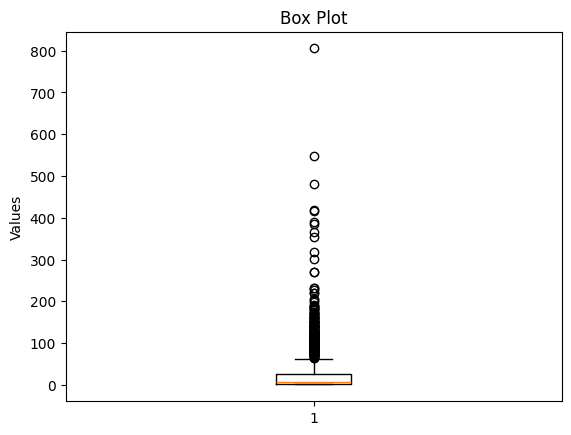

In [36]:


plt.boxplot(protein_count_lst)
plt.title("Box Plot")
plt.ylabel("Values")

plt.show()

In [1]:
import json

In [4]:
with open("/villa/rhh25/DSPTargetGen/output/predicted_targets.json", "r") as f:
    data = json.load(f)

In [6]:
len(data)

3743

In [7]:
3743+401

4144

In [3]:
pwd

'/villa/rhh25/Cellhit/notebooks'

In [16]:
"""
srf_pipeline.py
---------------
Reproduces Figure 1 of the Methodology section
("Methodology Pipeline: SRF for BME Stabilization").

Output: srf_pipeline.pdf in the same directory.

Dependencies:
    matplotlib >= 3.5
    numpy

Run:
    python srf_pipeline.py
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import (
    FancyBboxPatch, FancyArrowPatch, Circle, Wedge, Rectangle, Polygon, Arc,
)


# ---------------------------------------------------------------------------
# 0. Output path (defaults to the directory of this script)
# ---------------------------------------------------------------------------
#HERE = os.path.dirname(os.path.abspath(__file__))
OUT_PDF = '/villa/rhh25/Cellhit/notebooks/tokenomics_pipeline.svg'


# ---------------------------------------------------------------------------
# 1. Page geometry (inches)
# ---------------------------------------------------------------------------
W, H = 14.0, 9.0
P_W = 4.30          # pillar width
P_H = 7.40          # pillar height
P_GAP = 0.25        # horizontal gap between pillars
P_Y = 0.85          # bottom of each pillar

LEFT_MARGIN = (W - 3 * P_W - 2 * P_GAP) / 2
XS = [LEFT_MARGIN + i * (P_W + P_GAP) for i in range(3)]   # left edge of each pillar

PILLAR_COLORS = ["#264653", "#2A9D8F", "#E76F51"]
PILLAR_TITLES = [
    "System Model &\nTheoretical Framework",
    "Closed-Loop\nStabilization Engine",
    "Operational\nImplementation",
]
STAGE_OUTPUTS = [
    r"Output:  Dynamic Differential Equation System  ",
    r"Output:  Control signals  "
    r"$\{\Delta P_{\mathrm{SRF},t},\; \ell_t,\; \eta_t\}$",
    r"Output:  Simulated trajectories  "
    r"$\{P_t, R_t, \ell_t, \eta_t\}_{t=1}^{T}$",
]

HEADER_H = 0.85         # pillar header band height
INNER_PAD = 0.20        # padding between pillar wall and item-cells
STAGE_CHIP_H = 0.55     # height of the stage-output chip at the bottom of a pillar
STAGE_CHIP_GAP = 0.20   # gap between item-cells and the stage-output chip

# Item-cell layout
CELL_PAD_X = 0.30
CELL_PAD_TOP = 0.18
CELL_PAD_BOT = 0.22
TITLE_H = 0.28


# ---------------------------------------------------------------------------
# 2. Item-cell renderer
# ---------------------------------------------------------------------------
def draw_cell(ax, cx, cy, w, h, color, title, draw_icon):
    """Draw a single item sub-cell: subtle bg + bold title + icon zone."""
    # Subtle cell background
    ax.add_patch(FancyBboxPatch(
        (cx, cy), w, h,
        boxstyle="round,pad=0.01,rounding_size=0.06",
        linewidth=0, facecolor=color, alpha=0.04,
    ))

    # Title
    title_y = cy + h - CELL_PAD_TOP - TITLE_H / 2
    ax.text(cx + w / 2, title_y, title,
            ha="center", va="center",
            fontsize=11, fontweight="bold", color=color)

    # Icon zone (everything below the title, above the bottom padding)
    icon_top = cy + h - CELL_PAD_TOP - TITLE_H - 0.10
    icon_bot = cy + CELL_PAD_BOT
    icon_cx = cx + w / 2
    icon_cy = (icon_top + icon_bot) / 2
    icon_w_avail = w - 2 * CELL_PAD_X - 0.10
    icon_h_avail = icon_top - icon_bot
    draw_icon(ax, icon_cx, icon_cy, icon_w_avail, icon_h_avail, color)


# ---------------------------------------------------------------------------
# 3. Icon primitives (each draws inside [cx-mw/2, cy-mh/2, mw, mh])
# ---------------------------------------------------------------------------
def icon_state_vector(ax, cx, cy, mw, mh, color):
    """[ P | S | R | V ] — four boxed components inside square brackets."""
    labels = ["P", "S", "R", "V"]
    bw = min(0.42, (mw - 0.30) / 4 - 0.05)
    bh = min(0.42, mh * 0.55)
    sp = 0.10
    total = 4 * bw + 3 * sp
    x0 = cx - total / 2
    for i, lbl in enumerate(labels):
        ax.add_patch(FancyBboxPatch(
            (x0 + i * (bw + sp), cy - bh / 2), bw, bh,
            boxstyle="round,pad=0.01,rounding_size=0.06",
            linewidth=1.4, edgecolor=color, facecolor="white",
        ))
        ax.text(x0 + i * (bw + sp) + bw / 2, cy, lbl,
                ha="center", va="center",
                fontsize=11, fontweight="bold", color=color)
    ax.text(x0 - 0.16, cy, "[",
            ha="center", va="center", fontsize=20, color=color)
    ax.text(x0 + total + 0.16, cy, "]",
            ha="center", va="center", fontsize=20, color=color)


def icon_price_curve(ax, cx, cy, mw, mh, color):
    """Stochastic price trajectory with a crash dip (mini chart)."""
    bw = min(2.30, mw - 0.10)
    bh = min(0.85, mh - 0.05)
    np.random.seed(7)
    n = 70
    t = np.linspace(-bw / 2 * 0.92, bw / 2 * 0.92, n)
    y = 0.10 * np.cumsum(np.random.normal(0, 0.20, n))
    y[28:36] -= np.linspace(0, 0.55, 8)
    y[36:46] -= 0.55
    y[46:] += np.linspace(0, 0.32, n - 46)
    y = y - y.mean()
    y = (y / max(abs(y.max()), abs(y.min()))) * (bh * 0.40)
    # frame axes (subtle)
    ax.plot([cx - bw / 2, cx + bw / 2],
            [cy - bh / 2, cy - bh / 2], color="#bbb", lw=0.7)
    ax.plot([cx - bw / 2, cx - bw / 2],
            [cy - bh / 2, cy + bh / 2], color="#bbb", lw=0.7)
    ax.plot(cx + t, cy + y, color=color, lw=1.7)


def icon_supply(ax, cx, cy, mw, mh, color):
    """S_t bar with mint (in) and burn (out) arrows."""
    bw = min(1.10, mw * 0.55)
    bh = min(0.42, mh * 0.42)
    ax.add_patch(FancyBboxPatch(
        (cx - bw / 2, cy - bh / 2), bw, bh,
        boxstyle="round,pad=0.01,rounding_size=0.10",
        linewidth=1.4, edgecolor=color, facecolor=color, alpha=0.20,
    ))
    ax.text(cx, cy, r"$S_t$",
            ha="center", va="center",
            fontsize=12, color=color, fontweight="bold")
    # mint inflow (left)
    ax.add_patch(FancyArrowPatch(
        (cx - bw / 2 - 0.55, cy + 0.10),
        (cx - bw / 2 - 0.04, cy + 0.06),
        arrowstyle="->", mutation_scale=14, lw=1.4, color="#2A9D8F",
    ))
    ax.text(cx - bw / 2 - 0.55, cy + 0.30, "mint",
            ha="center", va="center", fontsize=8.5, color="#2A9D8F")
    # burn outflow (right)
    ax.add_patch(FancyArrowPatch(
        (cx + bw / 2 + 0.04, cy - 0.06),
        (cx + bw / 2 + 0.55, cy - 0.10),
        arrowstyle="->", mutation_scale=14, lw=1.4, color="#E76F51",
    ))
    ax.text(cx + bw / 2 + 0.55, cy - 0.30, "burn",
            ha="center", va="center", fontsize=8.5, color="#E76F51")


def icon_bucket(ax, cx, cy, mw, mh, color):
    """Leaky bucket (trapezoid) for the Liquidity Vortex / Reserve."""
    tw = min(1.30, mw * 0.62)
    bw = tw * 0.74
    h = min(0.70, mh * 0.62)
    pts = [(cx - tw / 2, cy + h / 2),
           (cx + tw / 2, cy + h / 2),
           (cx + bw / 2, cy - h / 2),
           (cx - bw / 2, cy - h / 2)]
    ax.add_patch(Polygon(pts, closed=True,
                         linewidth=1.4, edgecolor=color,
                         facecolor=color, alpha=0.18))
    # liquid level
    ax.plot([cx - tw / 2 * 0.92, cx + tw / 2 * 0.92],
            [cy + 0.03, cy + 0.03],
            color=color, lw=1.0, alpha=0.85)
    ax.text(cx, cy - 0.18, r"$R_t$",
            ha="center", va="center",
            fontsize=11, color=color, fontweight="bold")
    # tax inflow
    ax.add_patch(FancyArrowPatch(
        (cx - tw / 2 - 0.45, cy + h / 2 + 0.30),
        (cx - tw / 2 + 0.10, cy + h / 2 + 0.04),
        arrowstyle="->", mutation_scale=12, lw=1.3, color="#2A9D8F",
    ))
    ax.text(cx - tw / 2 - 0.55, cy + h / 2 + 0.22, "tax",
            ha="center", va="center", fontsize=8.5, color="#2A9D8F")
    # spend outflow (tap on the right)
    ax.add_patch(Rectangle((cx + bw / 2 - 0.02, cy - h / 2 + 0.02),
                           0.20, 0.06, color=color))
    ax.add_patch(FancyArrowPatch(
        (cx + bw / 2 + 0.20, cy - h / 2 + 0.05),
        (cx + bw / 2 + 0.55, cy - h / 2 - 0.10),
        arrowstyle="->", mutation_scale=12, lw=1.3, color="#E76F51",
    ))
    ax.text(cx + bw / 2 + 0.55, cy - h / 2 - 0.22, "spend",
            ha="center", va="center", fontsize=8.5, color="#E76F51")


def icon_pd_loop(ax, cx, cy, mw, mh, color):
    """Compact closed-loop block diagram: Σ → PD → market → feedback."""
    avail = min(mw - 0.10, 2.80)
    r = 0.13
    sx = cx - avail / 2 + 0.08    # sum-node center x

    ax.add_patch(Circle((sx, cy + 0.05), r,
                        edgecolor="#444", facecolor="white", lw=1.2))
    ax.text(sx, cy + 0.05, r"$\Sigma$",
            ha="center", va="center", fontsize=11)

    ctrl_x, cw, ch = sx + 0.30, 0.65, 0.36
    ax.add_patch(FancyBboxPatch(
        (ctrl_x, cy + 0.05 - ch / 2), cw, ch,
        boxstyle="round,pad=0.01,rounding_size=0.06",
        linewidth=1.3, edgecolor=color, facecolor=color, alpha=0.85,
    ))
    ax.text(ctrl_x + cw / 2, cy + 0.05, "PD",
            ha="center", va="center",
            fontsize=11, color="white", fontweight="bold")

    px, pw, ph = ctrl_x + cw + 0.20, 0.78, 0.36
    ax.add_patch(FancyBboxPatch(
        (px, cy + 0.05 - ph / 2), pw, ph,
        boxstyle="round,pad=0.01,rounding_size=0.06",
        linewidth=1.3, edgecolor="#1D3557", facecolor="#1D3557", alpha=0.88,
    ))
    ax.text(px + pw / 2, cy + 0.05, "market",
            ha="center", va="center",
            fontsize=10, color="white", fontweight="bold")

    ex = px + pw
    arrows = [
        ((sx - 0.30, cy + 0.05),       (sx - r - 0.01, cy + 0.05),  "->"),
        ((sx + r + 0.01, cy + 0.05),   (ctrl_x - 0.01, cy + 0.05),  "->"),
        ((ctrl_x + cw + 0.01, cy + 0.05), (px - 0.01, cy + 0.05),    "->"),
        ((ex, cy + 0.05),              (ex + 0.18, cy + 0.05),      "-"),
        ((ex + 0.18, cy + 0.05),       (ex + 0.18, cy - 0.40),      "-"),
        ((ex + 0.18, cy - 0.40),       (sx, cy - 0.40),             "-"),
        ((sx, cy - 0.40),              (sx, cy - r + 0.04),         "->"),
    ]
    for src, dst, style in arrows:
        ax.add_patch(FancyArrowPatch(src, dst,
                                     arrowstyle=style,
                                     mutation_scale=10, lw=1.1, color="#444"))


def icon_lock(ax, cx, cy, mw, mh, color):
    """Padlock + locked/free supply bar."""
    pw, ph = 0.50, 0.40
    px = cx - mw / 2 + 0.30
    ax.add_patch(FancyBboxPatch(
        (px, cy - ph / 2), pw, ph,
        boxstyle="round,pad=0.01,rounding_size=0.06",
        linewidth=1.4, edgecolor=color, facecolor=color, alpha=0.85,
    ))
    ax.add_patch(Arc((px + pw / 2, cy + ph / 2 + 0.02), 0.40, 0.40,
                     theta1=0, theta2=180, color=color, lw=1.8))
    ax.add_patch(Circle((px + pw / 2, cy + 0.05), 0.06, color="white"))

    bx = px + pw + 0.25
    bw = min(mw / 2 + mw / 2 - (bx - cx) - 0.15, 1.55)
    bh = 0.32
    ax.add_patch(Rectangle((bx, cy - bh / 2), bw, bh,
                           linewidth=1.0, edgecolor=color, facecolor="white"))
    ax.add_patch(Rectangle((bx, cy - bh / 2), bw * 0.55, bh,
                           linewidth=0, facecolor=color, alpha=0.65))
    ax.text(bx + bw * 0.55 / 2, cy, "locked",
            ha="center", va="center",
            fontsize=8.5, color="white", fontweight="bold")
    ax.text(bx + bw * 0.55 + (bw * 0.45) / 2, cy, "free",
            ha="center", va="center", fontsize=8.5, color=color)


def icon_gauge(ax, cx, cy, mw, mh, color):
    """Tri-zone gauge with a needle (safe / mid / cap)."""
    r = min(0.70, mh * 0.55, mw * 0.30)
    base_y = cy - 0.10

    ax.add_patch(Wedge((cx, base_y), r, 180, 240,
                       facecolor="#2A9D8F", alpha=0.45, edgecolor="none"))
    ax.add_patch(Wedge((cx, base_y), r, 240, 300,
                       facecolor="#E9C46A", alpha=0.50, edgecolor="none"))
    ax.add_patch(Wedge((cx, base_y), r, 300, 360,
                       facecolor="#E76F51", alpha=0.45, edgecolor="none"))
    ax.add_patch(Arc((cx, base_y), 2 * r, 2 * r,
                     theta1=180, theta2=360, color="#444", lw=1.2))

    ang = np.deg2rad(255)
    ax.plot([cx, cx + r * 0.85 * np.cos(ang)],
            [base_y, base_y + r * 0.85 * np.sin(ang)],
            color="#222", lw=2.0)
    ax.add_patch(Circle((cx, base_y), 0.05, color="#222"))

    ax.text(cx - r - 0.10, base_y - 0.06, "safe",
            ha="right", va="top", fontsize=8.5, color="#2A9D8F")
    ax.text(cx + r + 0.10, base_y - 0.06, "cap",
            ha="left", va="top", fontsize=8.5, color="#E76F51")


def icon_tax(ax, cx, cy, mw, mh, color):
    """volume bars  →  η_t ring  →  R_t mini-bucket."""
    seg = mw * 0.85
    left = cx - seg / 2
    bx0 = left + 0.05

    # volume bars
    for i, h in enumerate([0.18, 0.30, 0.22, 0.36]):
        ax.add_patch(Rectangle((bx0 + i * 0.10, cy - h / 2 - 0.02),
                               0.07, h, color=color, alpha=0.7))
    ax.text(bx0 + 0.18, cy + 0.30, "volume",
            ha="center", va="bottom", fontsize=8.3, color="#444")

    # η ring
    rx = left + seg / 2
    rr = 0.30
    ax.add_patch(Circle((rx, cy), rr,
                        facecolor="white", edgecolor=color, lw=1.7))
    ax.text(rx, cy, r"$\eta_t$",
            ha="center", va="center",
            fontsize=12, color=color, fontweight="bold")

    # arrows
    ax.add_patch(FancyArrowPatch((bx0 + 0.50, cy), (rx - rr - 0.02, cy),
                                 arrowstyle="->", mutation_scale=12,
                                 lw=1.2, color="#444"))
    bL = rx + rr + 0.20
    ax.add_patch(FancyArrowPatch((rx + rr + 0.02, cy), (bL, cy),
                                 arrowstyle="->", mutation_scale=12,
                                 lw=1.2, color="#444"))

    # mini reserve bucket
    btw, bbw, bh = 0.40, 0.30, 0.40
    pts = [(bL, cy + bh / 2),
           (bL + btw, cy + bh / 2),
           (bL + btw - (btw - bbw) / 2, cy - bh / 2),
           (bL + (btw - bbw) / 2, cy - bh / 2)]
    ax.add_patch(Polygon(pts, closed=True,
                         linewidth=1.2, edgecolor=color,
                         facecolor=color, alpha=0.20))
    ax.text(bL + btw / 2, cy, r"$R_t$",
            ha="center", va="center",
            fontsize=10, color=color, fontweight="bold")


def icon_data_input(ax, cx, cy, mw, mh, color):
    """Two file/document icons: returns + volume."""
    fw, fh, sp = 0.65, 0.65, 0.30
    total = 2 * fw + sp
    x0 = cx - total / 2
    for i, lbl in enumerate(["returns", "volume"]):
        ax.add_patch(FancyBboxPatch(
            (x0 + i * (fw + sp) + 0.05, cy - fh / 2 - 0.06), fw, fh,
            boxstyle="round,pad=0.01,rounding_size=0.06",
            linewidth=0, facecolor=color, alpha=0.18,
        ))
        ax.add_patch(FancyBboxPatch(
            (x0 + i * (fw + sp), cy - fh / 2), fw, fh,
            boxstyle="round,pad=0.01,rounding_size=0.06",
            linewidth=1.4, edgecolor=color, facecolor="white",
        ))
        for k in range(3):
            ax.plot([x0 + i * (fw + sp) + 0.10,
                     x0 + i * (fw + sp) + fw - 0.10],
                    [cy + 0.15 - k * 0.12, cy + 0.15 - k * 0.12],
                    color=color, lw=1.0, alpha=0.7)
        ax.text(x0 + i * (fw + sp) + fw / 2, cy - fh / 2 - 0.20, lbl,
                ha="center", va="top", fontsize=9, color="#444")


def icon_loop(ax, cx, cy, mw, mh, color):
    """Circular daily-loop arrow with 'daily / t → t+1'."""
    r = min(0.70, mh * 0.40, mw * 0.25)
    ax.add_patch(Arc((cx, cy), 2 * r, 2 * r,
                     theta1=30, theta2=330, color=color, lw=2.4))
    ax.add_patch(FancyArrowPatch(
        (cx + r * np.cos(np.deg2rad(40)), cy + r * np.sin(np.deg2rad(40))),
        (cx + r * np.cos(np.deg2rad(30)), cy + r * np.sin(np.deg2rad(30))),
        arrowstyle="->", mutation_scale=20, lw=2.4, color=color,
    ))
    for theta in [60, 150, 240, 330]:
        a = np.deg2rad(theta)
        ax.plot([cx + (r - 0.07) * np.cos(a), cx + (r + 0.07) * np.cos(a)],
                [cy + (r - 0.07) * np.sin(a), cy + (r + 0.07) * np.sin(a)],
                color=color, lw=1.6)
    ax.text(cx, cy + 0.07, "daily",
            ha="center", va="center",
            fontsize=10, color=color, fontweight="bold")
    ax.text(cx, cy - 0.10, r"$t \to t{+}1$",
            ha="center", va="center", fontsize=9.5, color="#222")


def icon_trajectories(ax, cx, cy, mw, mh, color):
    """2x2 grid of mini line-charts for P_t, R_t, ℓ_t, η_t."""
    np.random.seed(11)
    pw, ph = 0.78, 0.40
    sp_x, sp_y = 0.30, 0.28
    labels = [r"$P_t$", r"$R_t$", r"$\ell_t$", r"$\eta_t$"]
    coords = [
        (-pw / 2 - sp_x / 2,  ph / 2 + sp_y / 2),
        ( pw / 2 + sp_x / 2,  ph / 2 + sp_y / 2),
        (-pw / 2 - sp_x / 2, -ph / 2 - sp_y / 2),
        ( pw / 2 + sp_x / 2, -ph / 2 - sp_y / 2),
    ]
    for (dx, dy), lbl in zip(coords, labels):
        x0 = cx + dx - pw / 2
        y0 = cy + dy
        ax.add_patch(Rectangle((x0, y0 - ph / 2), pw, ph,
                               linewidth=1.0, edgecolor=color,
                               facecolor="white"))
        n = 32
        t = np.linspace(0, pw * 0.94, n) + x0 + 0.02
        y = np.cumsum(np.random.normal(0, 0.04, n))
        y = (y - y.min()) / (y.max() - y.min() + 1e-6) * (ph * 0.70)
        y = y + (y0 - ph * 0.35)
        ax.plot(t, y, color=color, lw=1.4)
        ax.text(x0 - 0.04, y0, lbl,
                ha="right", va="center",
                fontsize=10, color=color, fontweight="bold")


# ---------------------------------------------------------------------------
# 4. Pillar contents
# ---------------------------------------------------------------------------
PILLAR_ITEMS = [
    [
        ("State Vector",                 icon_state_vector),
        ("Price SDE",                    icon_price_curve),
        ("Supply Dynamics",              icon_supply),
        ("Reserve (Liquidity Vortex)",   icon_bucket),
    ],
    [
        ("PD Controller",                icon_pd_loop),
        ("Dynamic Collateral",           icon_lock),
        ("Safeguards",                   icon_gauge),
        ("Self-Financing Tax",           icon_tax),
    ],
    [
        ("Inputs & Calibration",         icon_data_input),
        ("Daily Integration Loop",       icon_loop),
        ("Output Trajectories",          icon_trajectories),
    ],
]


# ---------------------------------------------------------------------------
# 5. Render the figure
# ---------------------------------------------------------------------------
def render(out_pdf=OUT_PDF):
    fig, ax = plt.subplots(figsize=(W, H))
    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.axis("off")

    # Title
    ax.text(W / 2, H - 0.45,
            "Methodology Pipeline: SRF for BME Stabilization",
            ha="center", fontsize=15.5, fontweight="bold")

    # Render each pillar
    for x, color, title, items, stage_out in zip(
        XS, PILLAR_COLORS, PILLAR_TITLES, PILLAR_ITEMS, STAGE_OUTPUTS,
    ):
        # Outer rounded container
        ax.add_patch(FancyBboxPatch(
            (x, P_Y), P_W, P_H,
            boxstyle="round,pad=0.04,rounding_size=0.20",
            linewidth=2.0, edgecolor=color, facecolor="white",
        ))

        # Header band
        ax.add_patch(FancyBboxPatch(
            (x + 0.10, P_Y + P_H - HEADER_H - 0.10),
            P_W - 0.20, HEADER_H,
            boxstyle="round,pad=0.02,rounding_size=0.12",
            linewidth=0, facecolor=color, alpha=0.92,
        ))
        ax.text(x + P_W / 2, P_Y + P_H - HEADER_H / 2 - 0.10, title,
                ha="center", va="center",
                fontsize=12, fontweight="bold", color="white")

        # Stage-output chip (one per pillar, at the bottom)
        chip_x = x + INNER_PAD
        chip_w = P_W - 2 * INNER_PAD
        chip_y = P_Y + INNER_PAD
        chip_h = STAGE_CHIP_H
        ax.add_patch(FancyBboxPatch(
            (chip_x, chip_y), chip_w, chip_h,
            boxstyle="round,pad=0.02,rounding_size=0.10",
            linewidth=1.2, edgecolor=color, facecolor=color, alpha=0.14,
        ))
        ax.text(chip_x + chip_w / 2, chip_y + chip_h / 2,
                stage_out, ha="center", va="center",
                fontsize=9.2, color=color, style="italic")

        # Item-cells stack (above the stage-output chip)
        cells_top = P_Y + P_H - HEADER_H - 0.30
        cells_bot = P_Y + INNER_PAD + STAGE_CHIP_H + STAGE_CHIP_GAP
        avail_h = cells_top - cells_bot
        n_items = len(items)
        cell_h = avail_h / n_items
        cell_w = P_W - 2 * INNER_PAD
        cell_x = x + INNER_PAD

        for i, (lbl, drawfn) in enumerate(items):
            cell_y = cells_top - (i + 1) * cell_h + 0.05
            draw_cell(ax, cell_x, cell_y,
                      cell_w, cell_h - 0.05,
                      color, lbl, drawfn)

    # Inter-pillar arrows
    arrow_y = P_Y + P_H / 2
    for i in range(2):
        ax.add_patch(FancyArrowPatch(
            (XS[i] + P_W - 0.02, arrow_y),
            (XS[i + 1] + 0.02, arrow_y),
            arrowstyle="->", mutation_scale=24, lw=2.4, color="#444",
        ))

    plt.tight_layout()
    plt.savefig(out_pdf, bbox_inches="tight", facecolor="white", format="svg")
    plt.close(fig)
    print(f"saved: {out_pdf}")


if __name__ == "__main__":
    render()


saved: /villa/rhh25/Cellhit/notebooks/tokenomics_pipeline.svg


In [2]:
path = '/DATA/DATANAS2/rhh25/inteprete_dsp_dataset/final_graph_data/refined_drug_targets.json'

In [4]:
import json

with open(path, "r") as f:
    data = json.load(f)

In [5]:
data

[{'drug_name': 'VX-765',
  'cid': 11398092,
  'raw_votes': {'9606.ENSP00000337383': 5,
   '9606.ENSP00000263341': 5,
   '9606.ENSP00000351273': 2,
   '9606.ENSP00000398698': 2,
   '9606.ENSP00000226574': 4,
   '9606.ENSP00000363089': 1}},
 {'drug_name': 'prednisolone acetate',
  'cid': 5834,
  'raw_votes': {'9606.ENSP00000231509': 5,
   '9606.ENSP00000478255': 4,
   '9606.ENSP00000498939': 5,
   '9606.ENSP00000350815': 3,
   '9606.ENSP00000256958': 1,
   '9606.ENSP00000304845': 2,
   '9606.ENSP00000336528': 2,
   '9606.ENSP00000444810': 1,
   '9606.ENSP00000498246': 1,
   '9606.ENSP00000356438': 2,
   '9606.ENSP00000229795': 1,
   '9606.ENSP00000226574': 2,
   '9606.ENSP00000312262': 2,
   '9606.ENSP00000316786': 1,
   '9606.ENSP00000497931': 1,
   '9606.ENSP00000494609': 1,
   '9606.ENSP00000497274': 1,
   '9606.ENSP00000285238': 1,
   '9606.ENSP00000260682': 2,
   '9606.ENSP00000342007': 1,
   '9606.ENSP00000360372': 1,
   '9606.ENSP00000215832': 1}},
 {'drug_name': 'BAICALEIN',
  'c